# 03 - Análisis de nulos y mecanismos de ausencia

**VERSIÓN FINAL POST-SEPARACIÓN.** En esta versión los tratamientos de columnas estructurales y columnas con muchos nulos se aplican después de separar Argenprop y Zonaprop en venta/alquiler. Las decisiones se reducen a tres casos: borrar, mantener porque aparece en otros dataframes, o conservar para reconstrucción.


In [1]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)


REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de datasets preprocesados


In [2]:
PROCESSED_SOURCES = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_v1.csv',
    'df_preprocesado_argenprop': PROCESSED_DIR / 'df_preprocesado_argenprop_v1.csv',
    'df_preprocesado_zonaprop': PROCESSED_DIR / 'df_preprocesado_zonaprop_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_v1.csv',
}

missing = [str(p.relative_to(REPO_ROOT)) for p in PROCESSED_SOURCES.values() if not p.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos procesados. Ejecutar primero 02_normalizacion_y_limpieza.ipynb: ' + ', '.join(missing))

preprocesados = {}
for name, path in PROCESSED_SOURCES.items():
    preprocesados[name] = pd.read_csv(path, low_memory=False)
    globals()[name] = preprocesados[name]
    print(name, preprocesados[name].shape)


df_preprocesado_meli_alq (11479, 72)
df_preprocesado_meli_alq_temp (6190, 72)
df_preprocesado_meli_vtas (44013, 72)
df_preprocesado_argenprop (162, 107)
df_preprocesado_zonaprop (980, 107)
df_preprocesado_airbnb_temp (9596, 73)


# Estrategia a utilizar
Se crean flags para cada variable con nulos, identificando si la columna es nula en cada fila

Luego se comparan estos flags contra variables cuantitaitivas y cualitativas para analizar posibles correlaciones. 


## Funciones para flags y gráficos de faltantes


In [3]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False


def add_null_flags(df, exclude=None):
    out = df.copy()
    exclude = set(exclude or [])
    original_cols = [c for c in out.columns if c not in exclude and not c.endswith('_is_null')]
    for col in original_cols:
        if out[col].isna().any():
            out[f'{col}_is_null'] = out[col].isna().astype('int8')
    return out


def seleccionar_flags_informativos(df, min_pct=2, max_pct=98, max_flags=18):
    flag_cols = [c for c in df.columns if c.endswith('_is_null')]
    if not flag_cols:
        return []
    pct = df[flag_cols].mean().mul(100).sort_values(ascending=False)
    return pct[(pct >= min_pct) & (pct <= max_pct)].head(max_flags).index.tolist()


def seleccionar_cuantitativas_informativas(df, max_vars=14):
    candidatas_prioritarias = [
        'precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado',
        'superficie_ref_m2', 'superficie_min_m2', 'superficie_max_m2', 'superficie_total_m2',
        'superficie_cubierta_m2', 'ambientes_ref', 'ambientes', 'ambientes_min', 'ambientes_max',
        'dormitorios_ref', 'dormitorios', 'banios_ref', 'banios', 'comuna', 'altura',
        'latitud', 'longitud', 'rating', 'reviews', 'cantidad_imagenes', 'capacidad', 'camas'
    ]
    cols = []
    for col in candidatas_prioritarias:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        if df[col].notna().mean() < 0.05:
            continue
        if df[col].nunique(dropna=True) <= 1:
            continue
        cols.append(col)
    return cols[:max_vars]


def plot_heatmap_matriz(data, title, figsize=(12, 8), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, mostrar_nan_como_cero=True):
    if data.empty:
        print(f'No hay datos suficientes para graficar: {title}')
        return
    data_plot = data.copy()
    if mostrar_nan_como_cero:
        data_plot = data_plot.fillna(0)
    plt.figure(figsize=figsize)
    if HAS_SEABORN:
        sns.heatmap(data_plot, annot=annot, fmt=fmt, cmap=cmap, center=center, vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white', cbar_kws={'label': 'Correlacion'})
    else:
        plt.imshow(data_plot, cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(label='Correlacion')
        plt.xticks(range(len(data_plot.columns)), data_plot.columns, rotation=90)
        plt.yticks(range(len(data_plot.index)), data_plot.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def seleccionar_flags_problematicos(df, min_pct=2, max_pct=98, top_n=10):
    flag_cols = [c for c in df.columns if c.endswith('_is_null')]
    if not flag_cols:
        return []
    resumen = df[flag_cols].mean().mul(100).sort_values(ascending=False).reset_index()
    resumen.columns = ['flag', 'pct_faltante']
    resumen = resumen[(resumen['pct_faltante'] >= min_pct) & (resumen['pct_faltante'] <= max_pct)]
    return resumen.head(top_n)['flag'].tolist()


def seleccionar_categoricas_informativas(df, max_cols=6):
    candidatas_prioritarias = [
        'fuente_norm', 'tipo_operacion_norm', 'moneda_norm', 'barrio_norm', 'tipo_propiedad',
        'localidad', 'provincia', 'inmobiliaria', 'seller_superhost', 'precio_sospechoso',
        'unidad_precio', 'precio_regimen', 'categoria_alojamiento', 'room_type'
    ]
    cols = []
    for col in candidatas_prioritarias:
        if col not in df.columns:
            continue
        n_labels = df[col].nunique(dropna=True)
        pct_no_nulo = df[col].notna().mean()
        if pct_no_nulo < 0.05:
            continue
        if n_labels < 2 or n_labels > 80:
            continue
        cols.append(col)
    return cols[:max_cols]


def faltantes_por_labels_categoricos(df, cat_cols, flag_cols, dataset_name, min_count=30, top_labels_por_col=25):
    rows = []
    for cat_col in cat_cols:
        if cat_col not in df.columns:
            continue
        serie_cat = df[cat_col].astype('string').fillna(f'NULO_EN_{cat_col}')
        labels_validos = serie_cat.value_counts(dropna=False).head(top_labels_por_col).index
        for label in labels_validos:
            mask = serie_cat == label
            n = int(mask.sum())
            if n < min_count:
                continue
            for flag_col in flag_cols:
                if flag_col not in df.columns:
                    continue
                if flag_col == f'{cat_col}_is_null':
                    continue
                rows.append({
                    'dataset': dataset_name,
                    'variable_categorica': cat_col,
                    'label': label,
                    'n_registros': n,
                    'variable_faltante': flag_col,
                    'pct_faltante': round(df.loc[mask, flag_col].mean() * 100, 2),
                })
    return pd.DataFrame(rows)


def graficar_faltantes_por_label(df_resumen, dataset_name):
    if df_resumen.empty:
        print(f'No se genero tabla de faltantes por label para {dataset_name}.')
        return
    df_pivot = df_resumen.pivot_table(
        index=['variable_categorica', 'label'],
        columns='variable_faltante',
        values='pct_faltante',
        aggfunc='mean'
    ).fillna(0)
    if df_pivot.empty:
        print(f'No hay datos suficientes para graficar {dataset_name}.')
        return
    variables_unicas = list(df_pivot.index.get_level_values('variable_categorica').unique())
    alto = min(22, max(7, len(df_pivot) * 0.32))
    if HAS_SEABORN:
        paleta = sns.color_palette('Set2', n_colors=len(variables_unicas))
        mapa_colores = dict(zip(variables_unicas, paleta))
        colores_filas = [mapa_colores[v] for v in df_pivot.index.get_level_values('variable_categorica')]
        g = sns.clustermap(
            df_pivot,
            row_cluster=False,
            col_cluster=False,
            row_colors=colores_filas,
            cmap='YlOrRd',
            annot=True,
            fmt='.1f',
            linewidths=0.5,
            figsize=(14, alto),
        )
        g.fig.suptitle(f'Porcentaje de faltantes por label categorico - {dataset_name}', y=1.02)
        plt.show()
    else:
        plt.figure(figsize=(14, alto))
        plt.imshow(df_pivot.values, aspect='auto')
        plt.colorbar(label='% faltante')
        plt.xticks(range(len(df_pivot.columns)), df_pivot.columns, rotation=90)
        plt.yticks(range(len(df_pivot.index)), [f'{a} = {b}' for a, b in df_pivot.index], fontsize=8)
        plt.title(f'Porcentaje de faltantes por label categorico - {dataset_name}')
        plt.tight_layout()
        plt.show()


## Creación de flags de nulidad por dataset original


In [4]:
preprocesados_con_flags = {}
for name, df in preprocesados.items():
    preprocesados_con_flags[name] = add_null_flags(df)
    globals()[name] = preprocesados_con_flags[name]
    print(name, 'flags creados:', sum(c.endswith('_is_null') for c in preprocesados_con_flags[name].columns))


df_preprocesado_meli_alq flags creados: 31
df_preprocesado_meli_alq_temp flags creados: 32
df_preprocesado_meli_vtas flags creados: 33
df_preprocesado_argenprop flags creados: 79
df_preprocesado_zonaprop flags creados: 82
df_preprocesado_airbnb_temp flags creados: 17


## Celdas de decisión: estrategia inicial de nulos

Antes de aplicar ajustes, se conserva una estrategia conservadora: flaggear y analizar. La imputación o eliminación se decide después de revisar los patrones.


In [5]:
# Estrategia conservadora por defecto.
# Opciones esperadas: 'flaggear', 'eliminar_criticos'
ESTRATEGIA_NULOS = 'flaggear'
CAMPOS_CRITICOS_NULOS = ['precio', 'moneda_norm', 'barrio_norm', 'tipo_operacion_norm']

resumen_estrategia_nulos = []
for name, df in preprocesados_con_flags.items():
    campos_existentes = [c for c in CAMPOS_CRITICOS_NULOS if c in df.columns]
    filas_antes = len(df)
    filas_con_nulo_critico = int(df[campos_existentes].isna().any(axis=1).sum()) if campos_existentes else 0

    if ESTRATEGIA_NULOS == 'eliminar_criticos' and campos_existentes:
        preprocesados_con_flags[name] = df.dropna(subset=campos_existentes).copy()
        accion = 'eliminados registros con nulos en campos criticos'
    else:
        accion = 'solo flags; no se eliminan registros'

    resumen_estrategia_nulos.append({
        'dataset': name,
        'estrategia': ESTRATEGIA_NULOS,
        'campos_criticos_existentes': ', '.join(campos_existentes),
        'filas_antes': filas_antes,
        'filas_con_nulo_critico': filas_con_nulo_critico,
        'filas_despues': len(preprocesados_con_flags[name]),
        'accion': accion,
    })

resumen_estrategia_nulos = pd.DataFrame(resumen_estrategia_nulos)
print('Reporte de estrategia de nulos guardado:', (REPORTS_DIR / 'decisiones_tratamiento_nulos_v1.csv').relative_to(REPO_ROOT))
resumen_estrategia_nulos.to_csv(REPORTS_DIR / 'decisiones_tratamiento_nulos_v1.csv', index=False)


Reporte de estrategia de nulos guardado: data\processed\reports\decisiones_tratamiento_nulos_v1.csv


## Matrices de faltantes por dataset

Tal como hicimos en el caso practico de las clases del 23 y 24 de septiembre, se muestran dos matrices de correlaciones por dataset:

1. **Faltante vs faltante**, para ver ausencias que aparecen juntas.
2. **Faltante vs cuantitativas**, para ver si la ausencia de un campo se asocia con precio, superficie, ambientes, rating u otras variables numéricas.

Estas matrices permiten analizar si los faltantes se correlacionan con otros faltantes o con variables cuantitativas. 



df_preprocesado_meli_alq


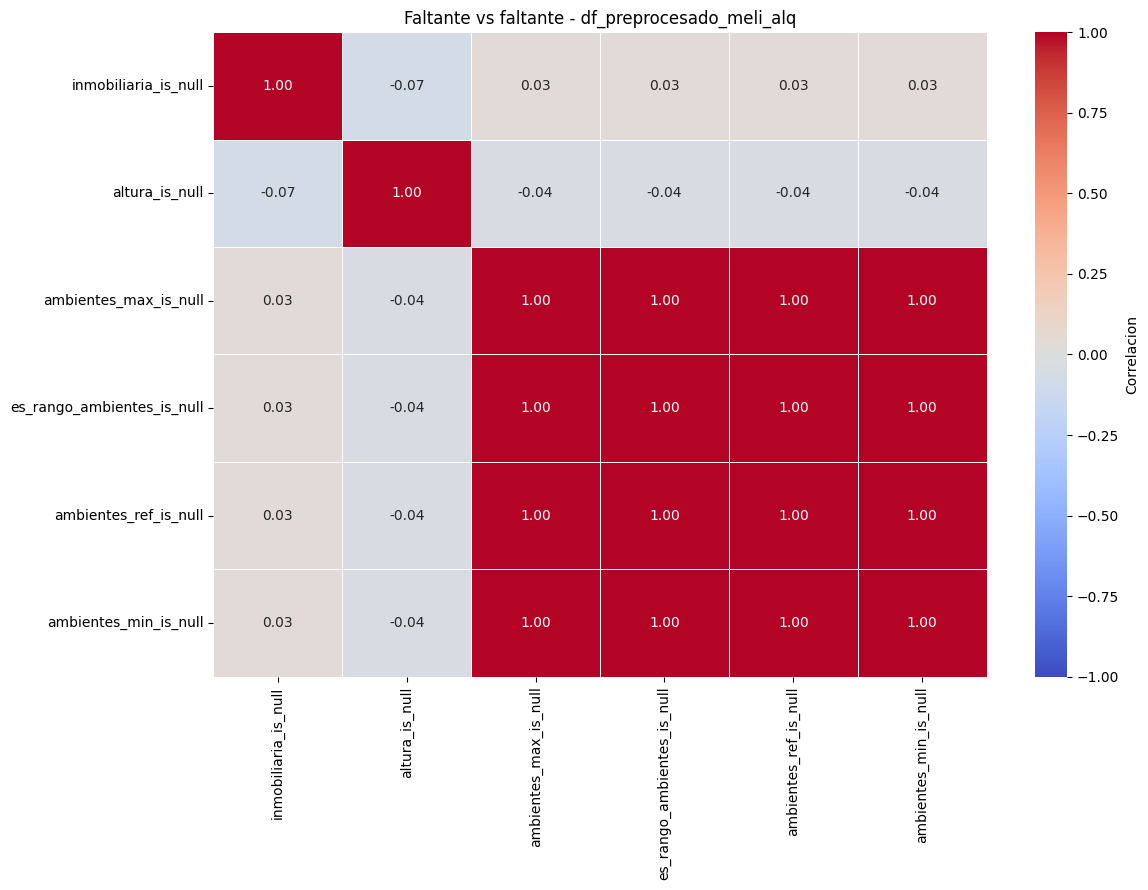

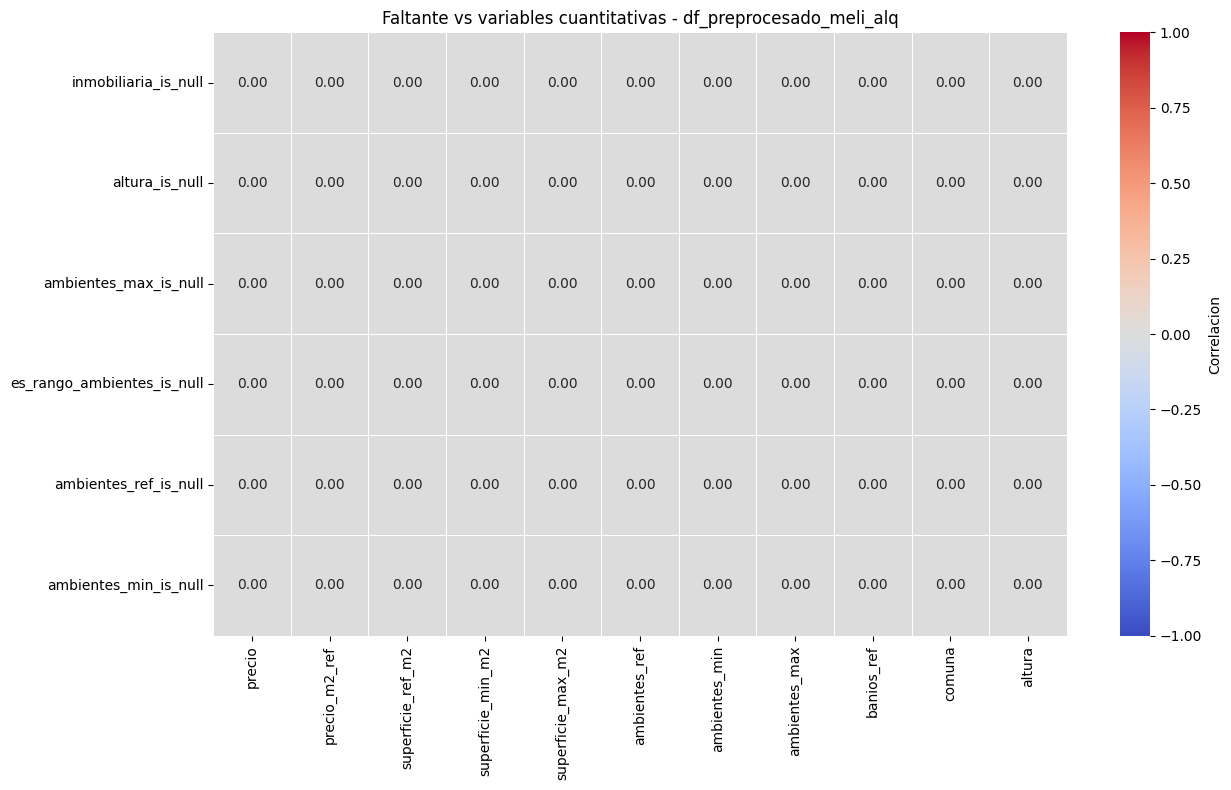


df_preprocesado_meli_alq_temp


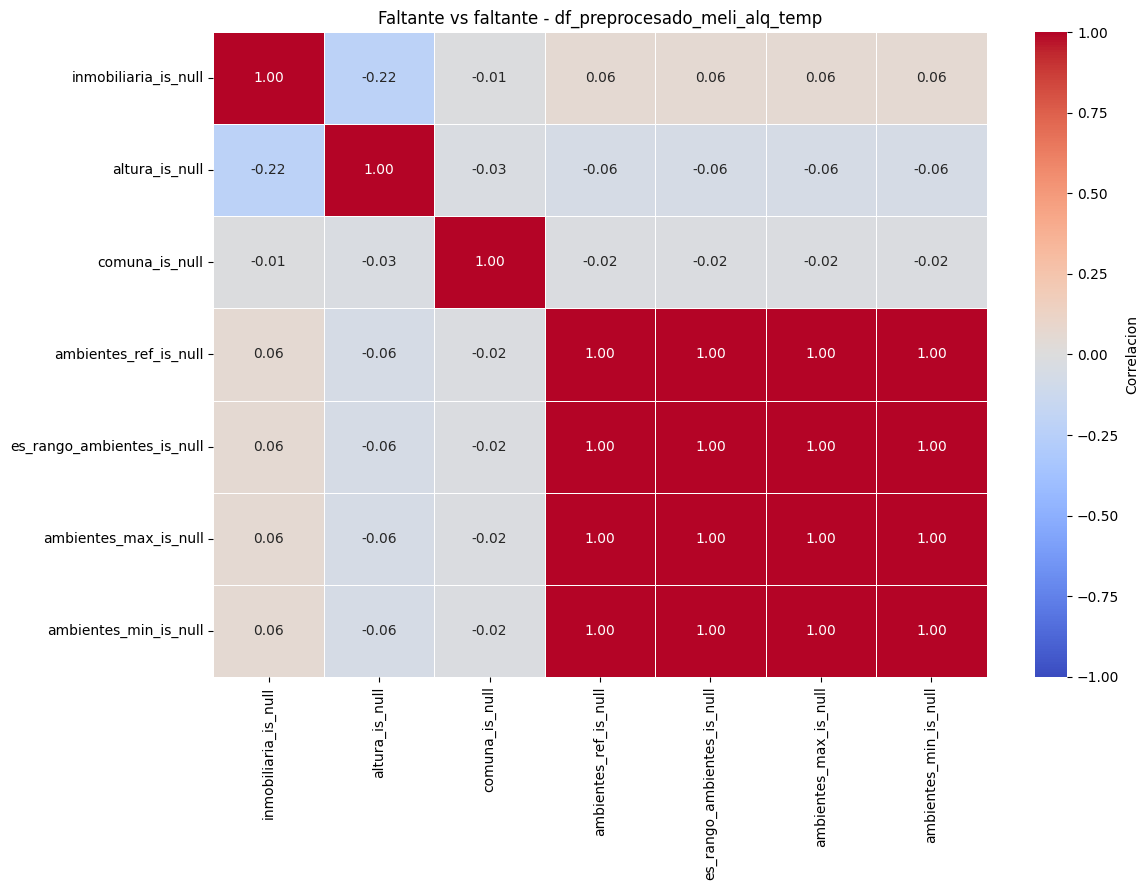

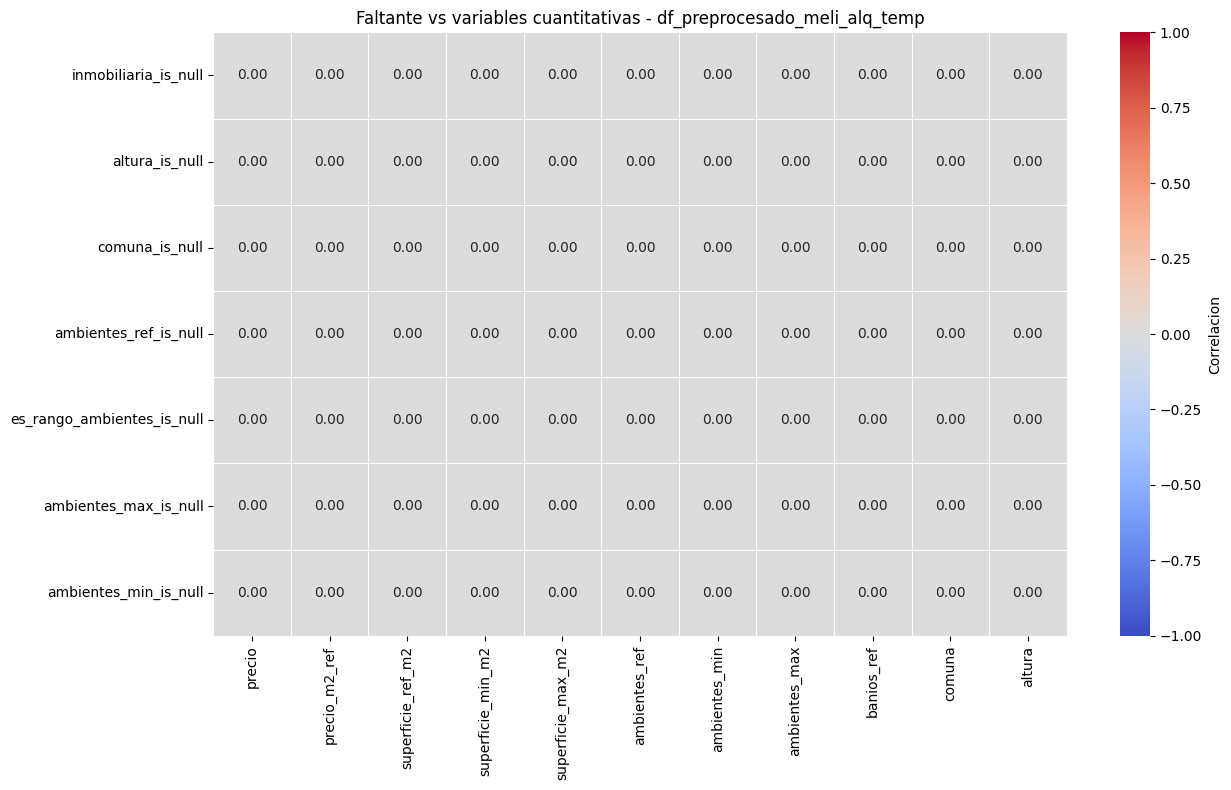


df_preprocesado_meli_vtas


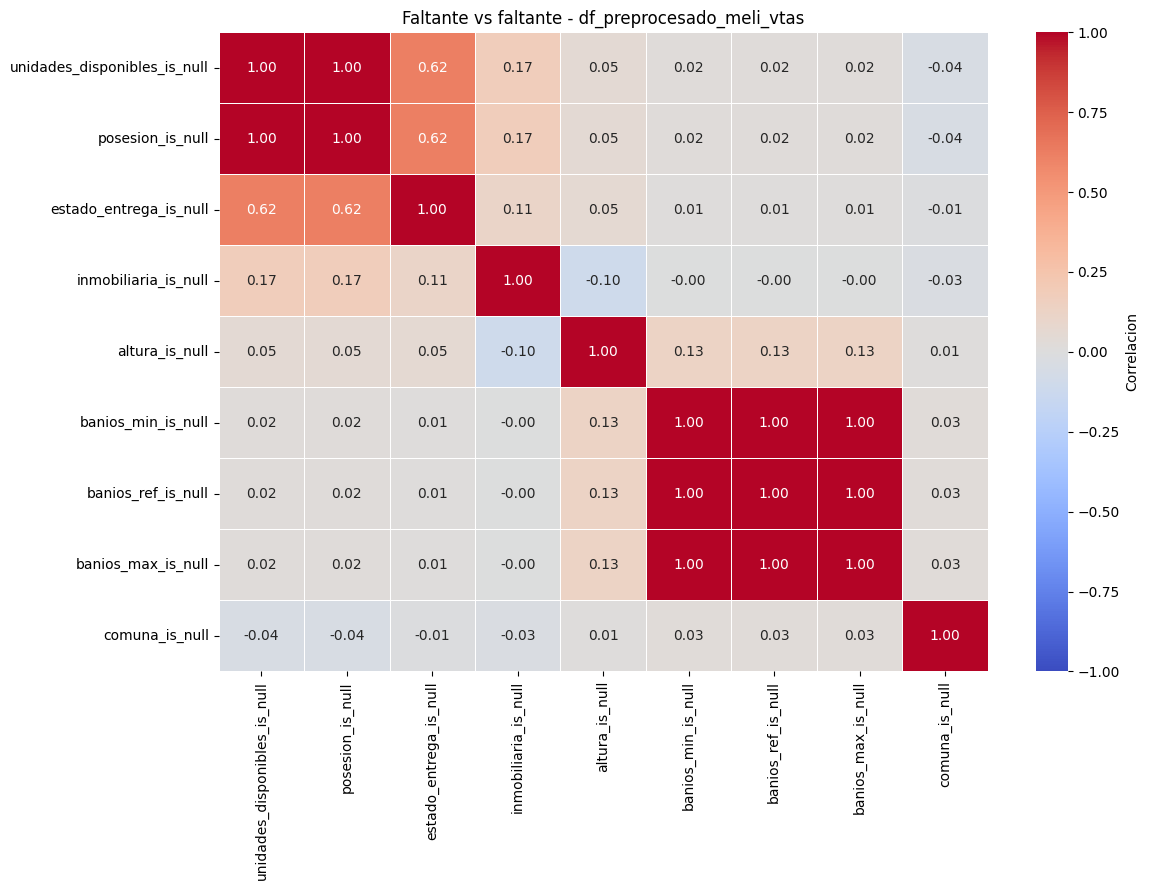

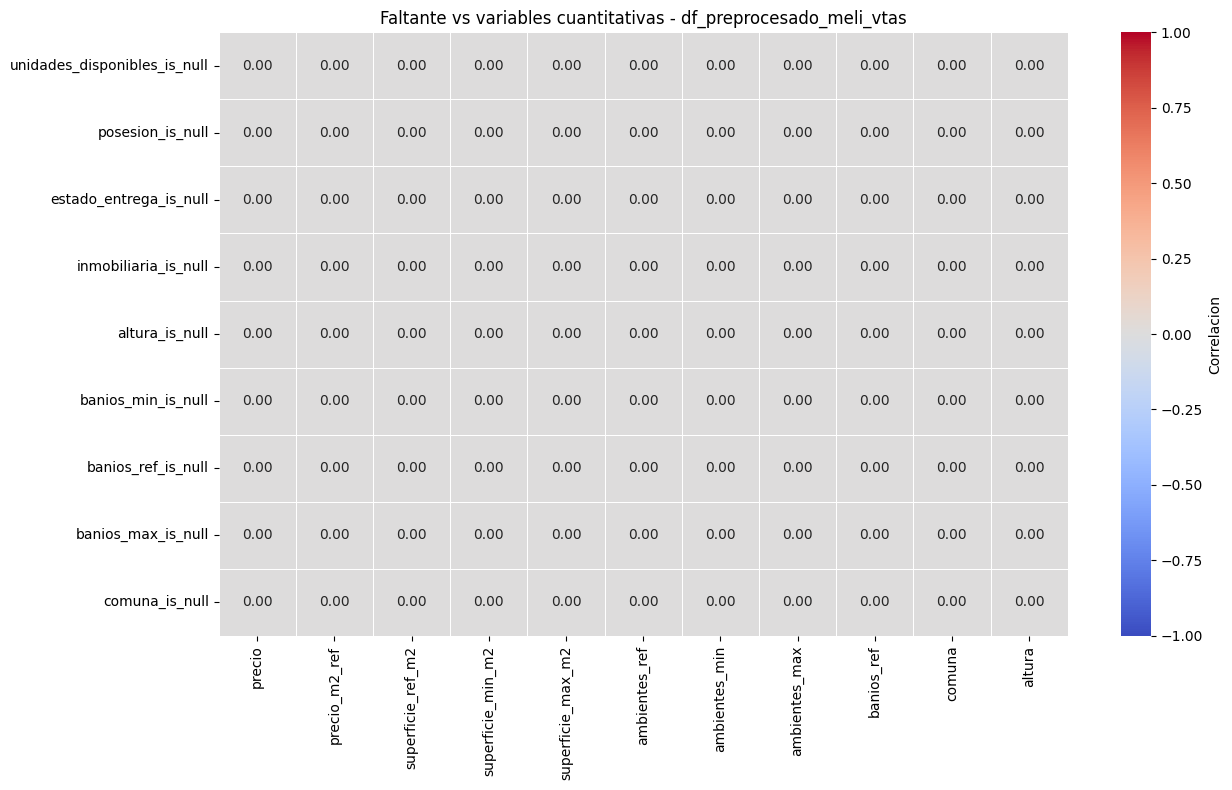


df_preprocesado_argenprop


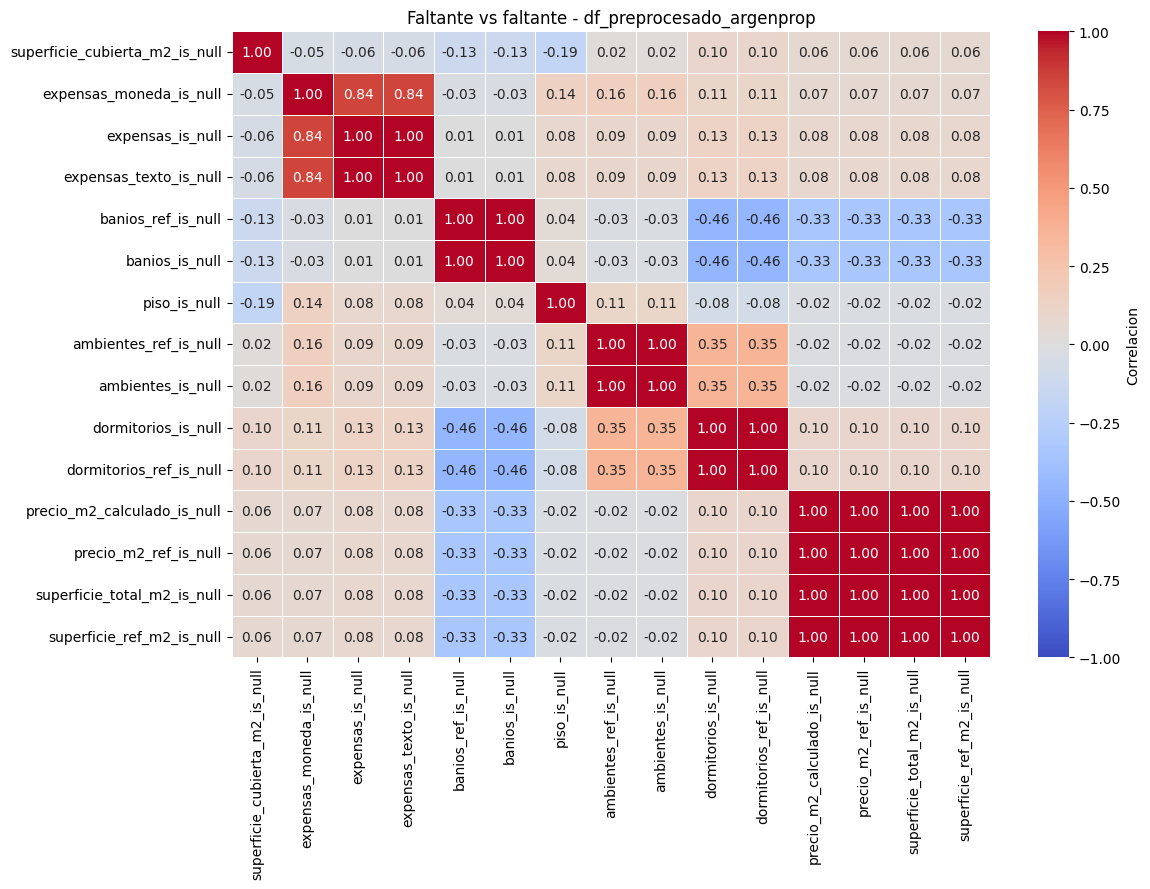

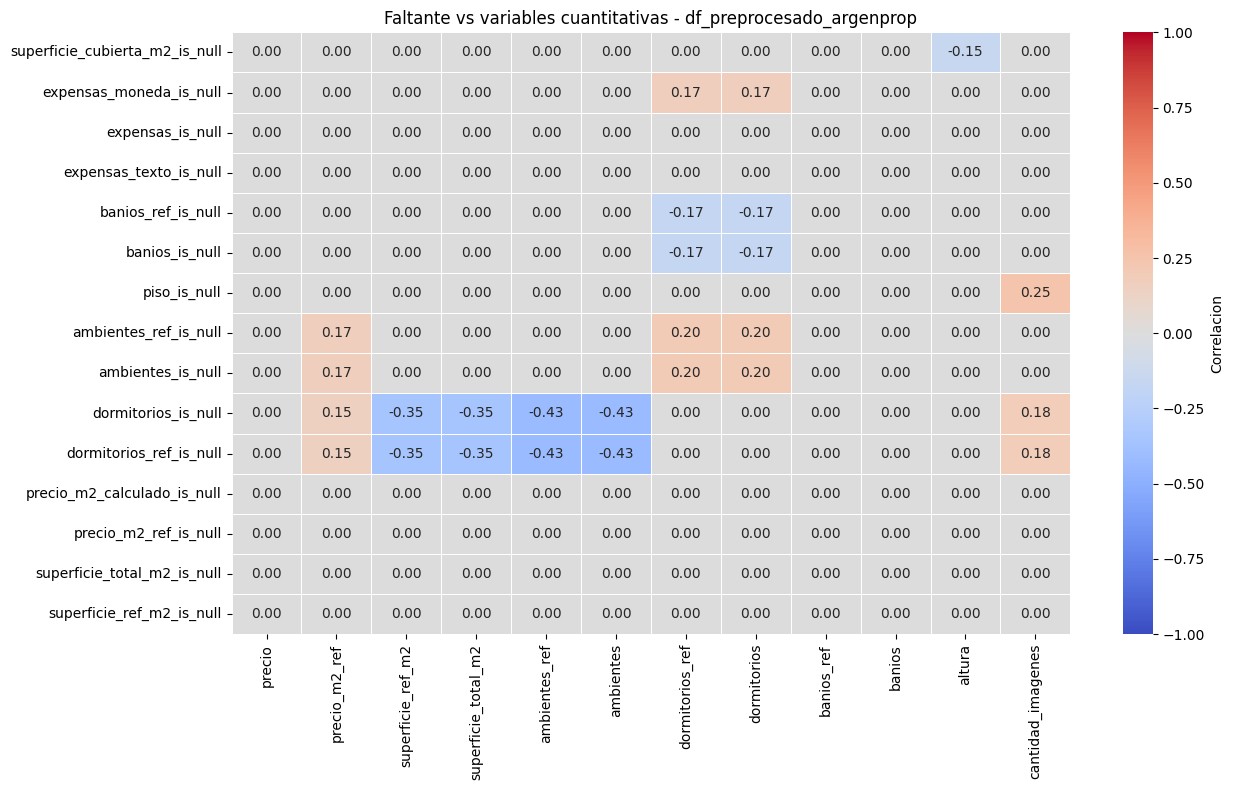


df_preprocesado_zonaprop


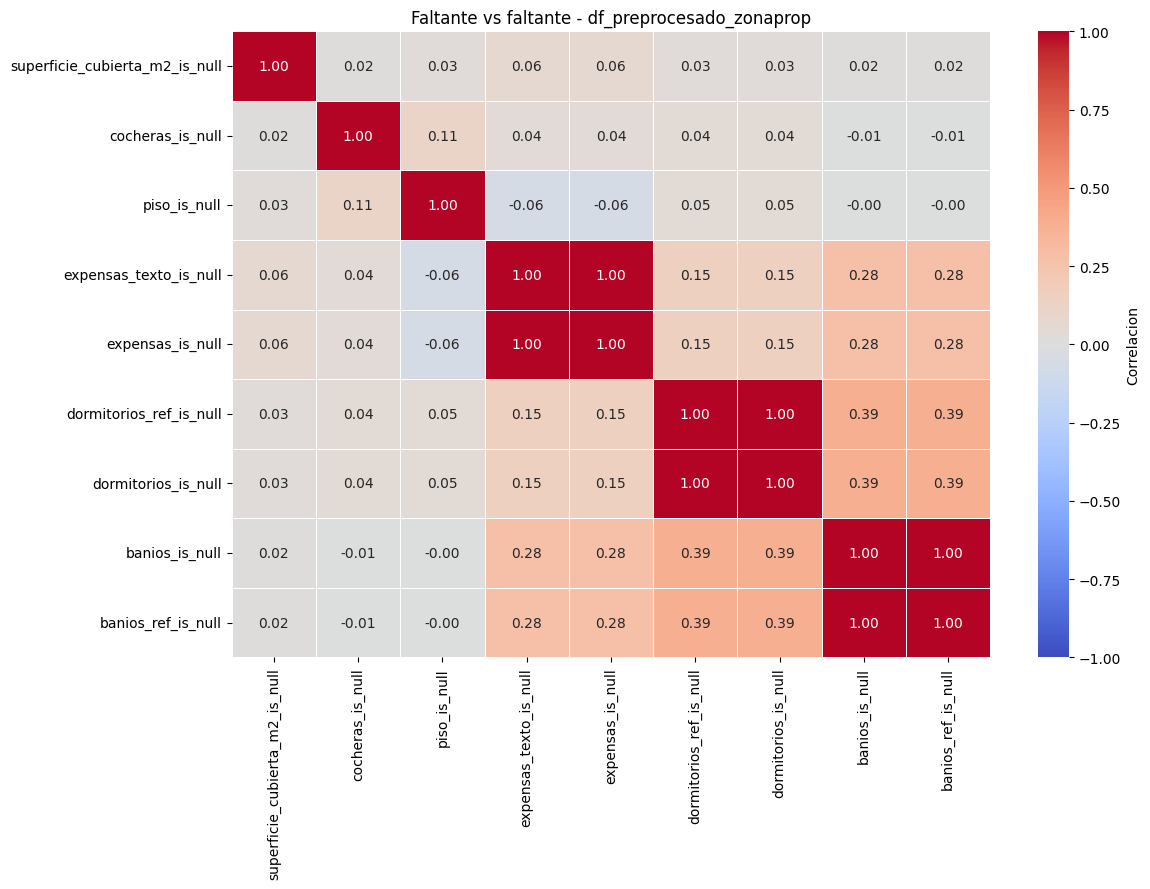

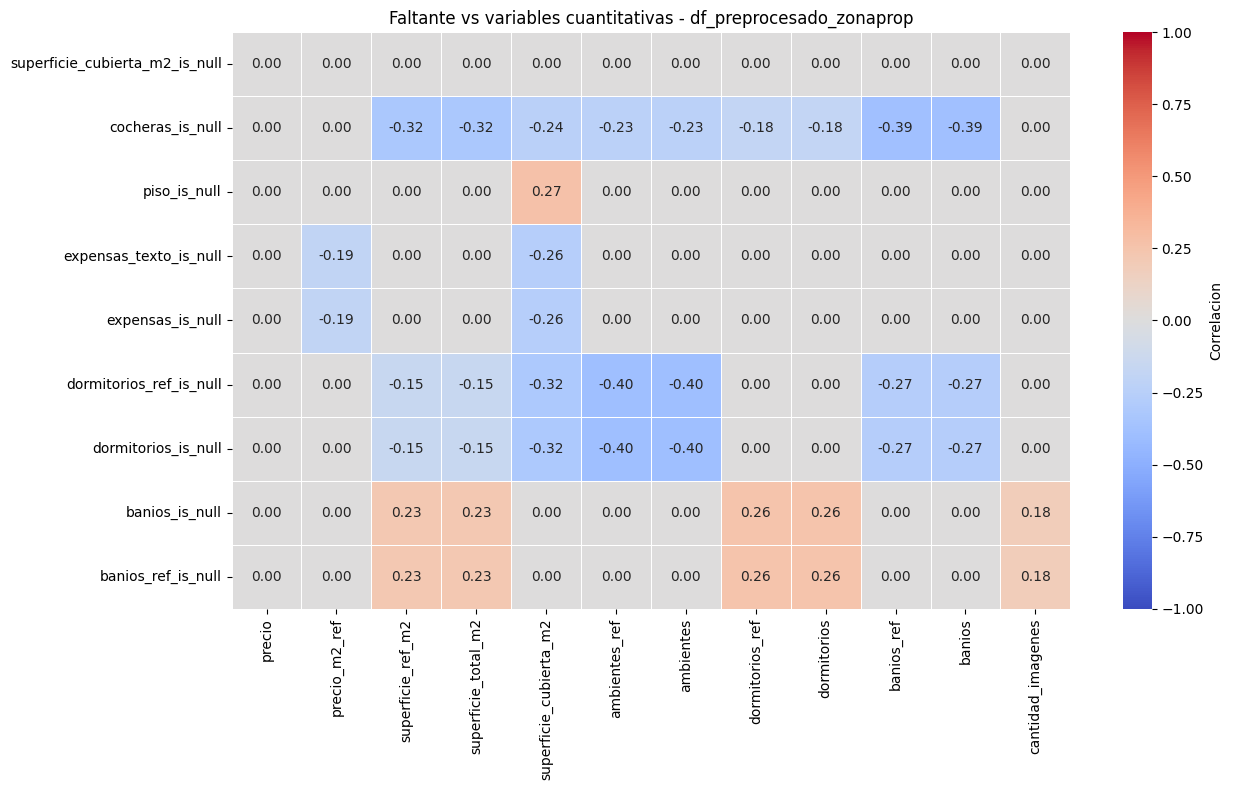


df_preprocesado_airbnb_temp


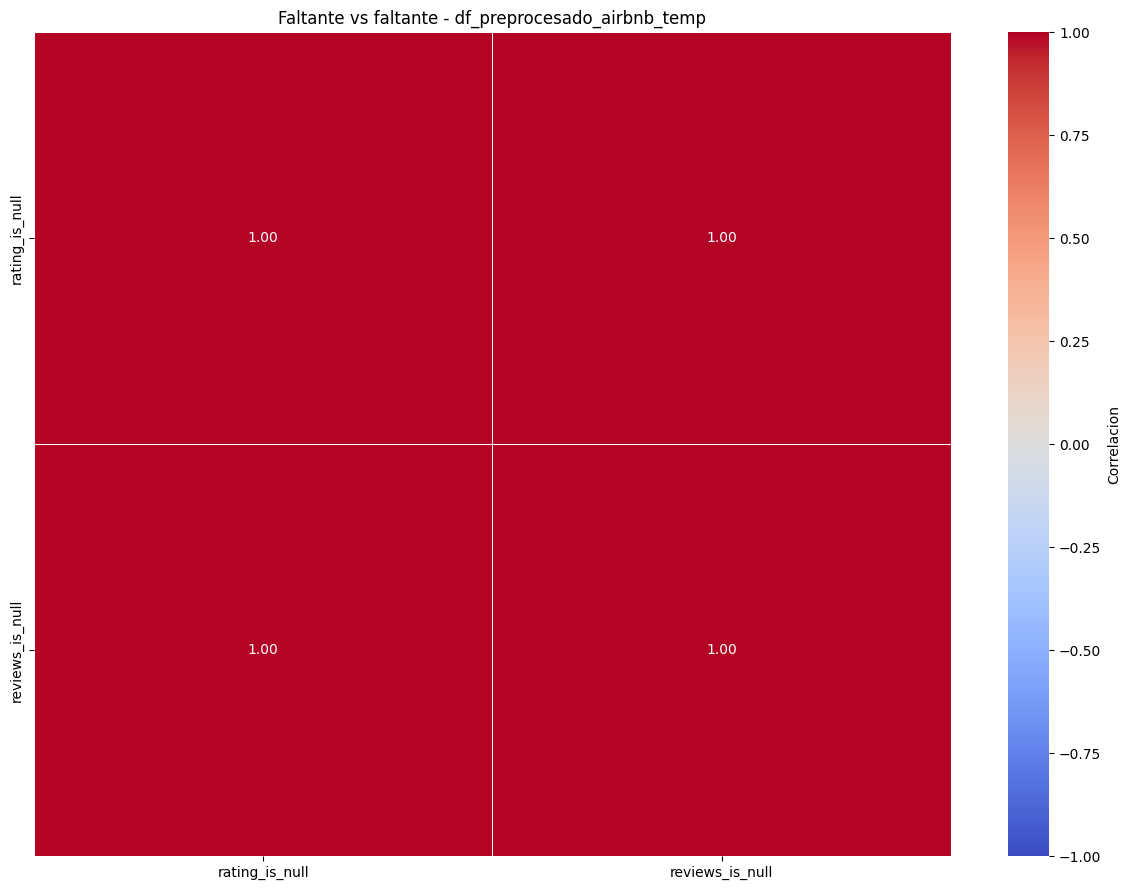

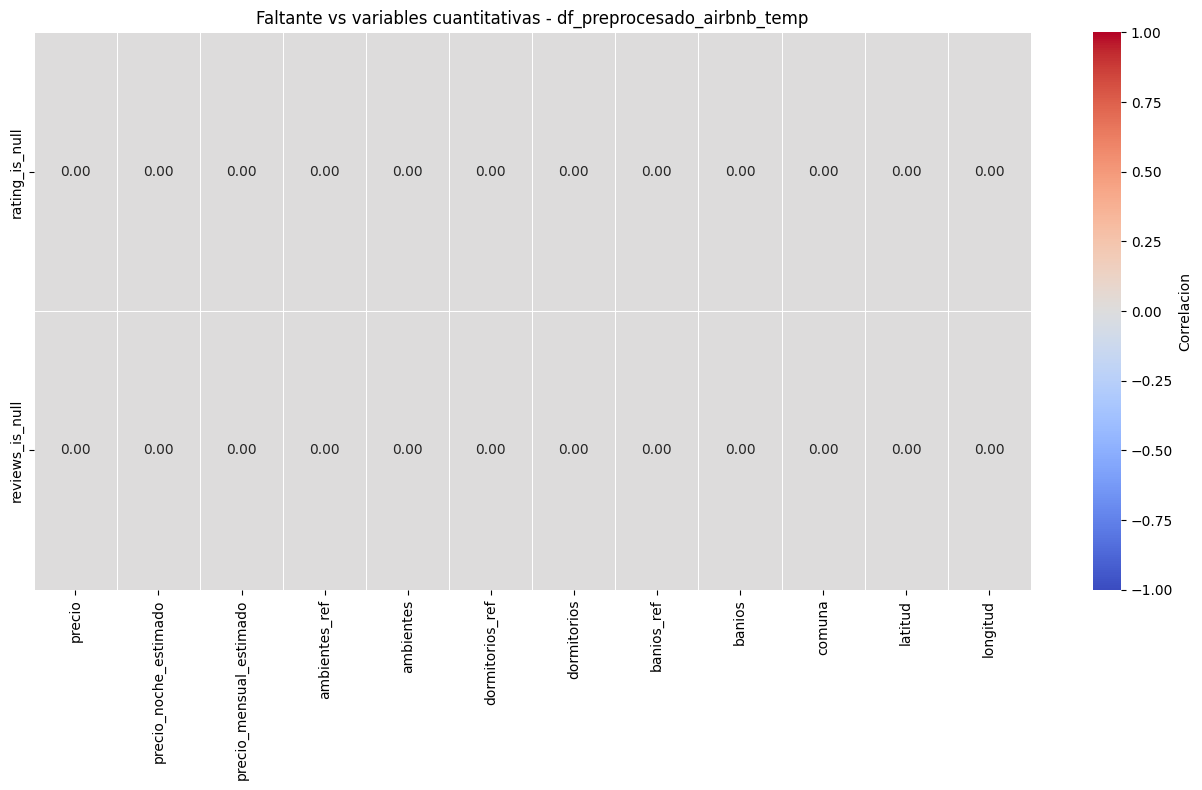

In [6]:
for name, df in preprocesados_con_flags.items():
    print('\n' + '=' * 100)
    print(name)

    flags = seleccionar_flags_informativos(df, min_pct=2, max_pct=98, max_flags=16)
    cuantitativas = seleccionar_cuantitativas_informativas(df, max_vars=12)

    if len(flags) < 2:
        print('No hay suficientes flags informativos de faltantes para este dataset.')
        continue

    matriz_faltante_faltante = df[flags].corr()
    matriz_faltante_faltante.to_csv(REPORTS_DIR / f'matriz_faltante_vs_faltante_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_faltante, title=f'Faltante vs faltante - {name}', figsize=(12, 9), annot=True, mostrar_nan_como_cero=True)

    if len(cuantitativas) == 0:
        print('No hay variables cuantitativas informativas para cruzar contra faltantes.')
        continue

    matriz_faltante_cuantitativa = df[flags + cuantitativas].corr(numeric_only=True).loc[flags, cuantitativas]
    umbral_corr_cuantitativas = 0.15
    matriz_faltante_cuantitativa_filtrada = matriz_faltante_cuantitativa.where(matriz_faltante_cuantitativa.abs() >= umbral_corr_cuantitativas, other=0)
    matriz_faltante_cuantitativa.to_csv(REPORTS_DIR / f'matriz_faltante_vs_cuantitativas_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_cuantitativa_filtrada, title=f'Faltante vs variables cuantitativas - {name}', figsize=(13, 8), annot=True, mostrar_nan_como_cero=True)


# Conclusiones de correlaciones originales

### MeLi alquiler
Se nota un bloque de correlaciones fuertes en variables de rangos de ambientes, mínimos y máximos. Esto sugiere que varias ausencias no son aleatorias sino que dependen de cómo la publicación estructura los atributos.

### Argenprop y Zonaprop combinados
En esta primera lectura aparecen mezcladas publicaciones de venta y alquiler dentro de una misma fuente. Eso puede inflar o esconder relaciones entre faltantes, porque una operación puede tener campos naturalmente más presentes que otra. Por eso se decide generar una segunda lectura separando por `tipo_operacion_norm`.

### Las Cañitas
En las matrices y tablas por label aparece `Las Cañitas / las canitas` como barrio operativo con comuna faltante. Como no es barrio oficial de CABA sino subzona de Palermo, se decide corregirlo **después** de observar el problema: normalizarlo como `palermo` y completar `comuna = 14`.

### Localidad
En algunos dataframes `localidad` toma siempre el mismo valor asociado a CABA. Como el alcance del TP ya está definido sobre propiedades en CABA, esa columna no agrega segmentación ni capacidad explicativa. Se decide eliminarla cuando sea constante.

### Moneda
En algunos dataframes `moneda_norm` tiene una sola etiqueta. Aun así se conserva, porque en otros datasets sí hay más de una moneda y la variable es necesaria para comparar precios y documentar conversiones.


## Faltantes por label de variables categóricas, discriminado por dataset

Este análisis evita que el consolidado quede dominado por diferencias de estructura entre fuentes. Para cada dataset se cruzan flags de faltantes contra labels de variables categóricas existentes en ese mismo dataset.



df_preprocesado_meli_alq


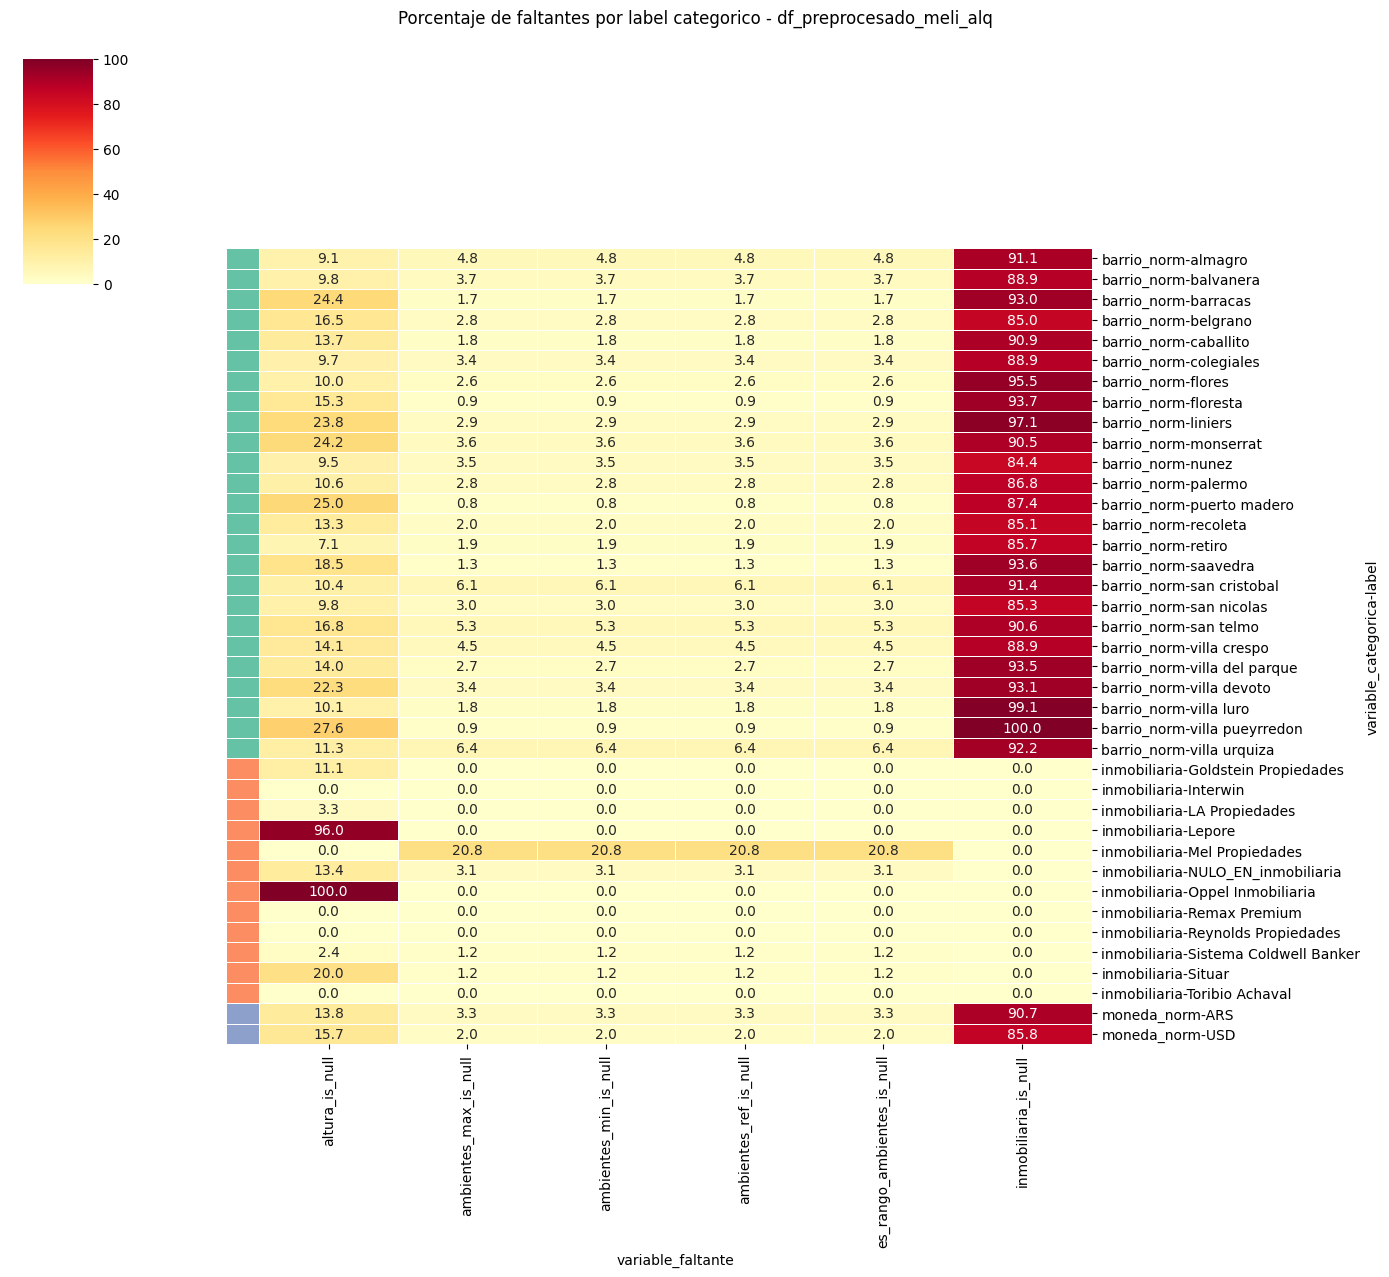


df_preprocesado_meli_alq_temp


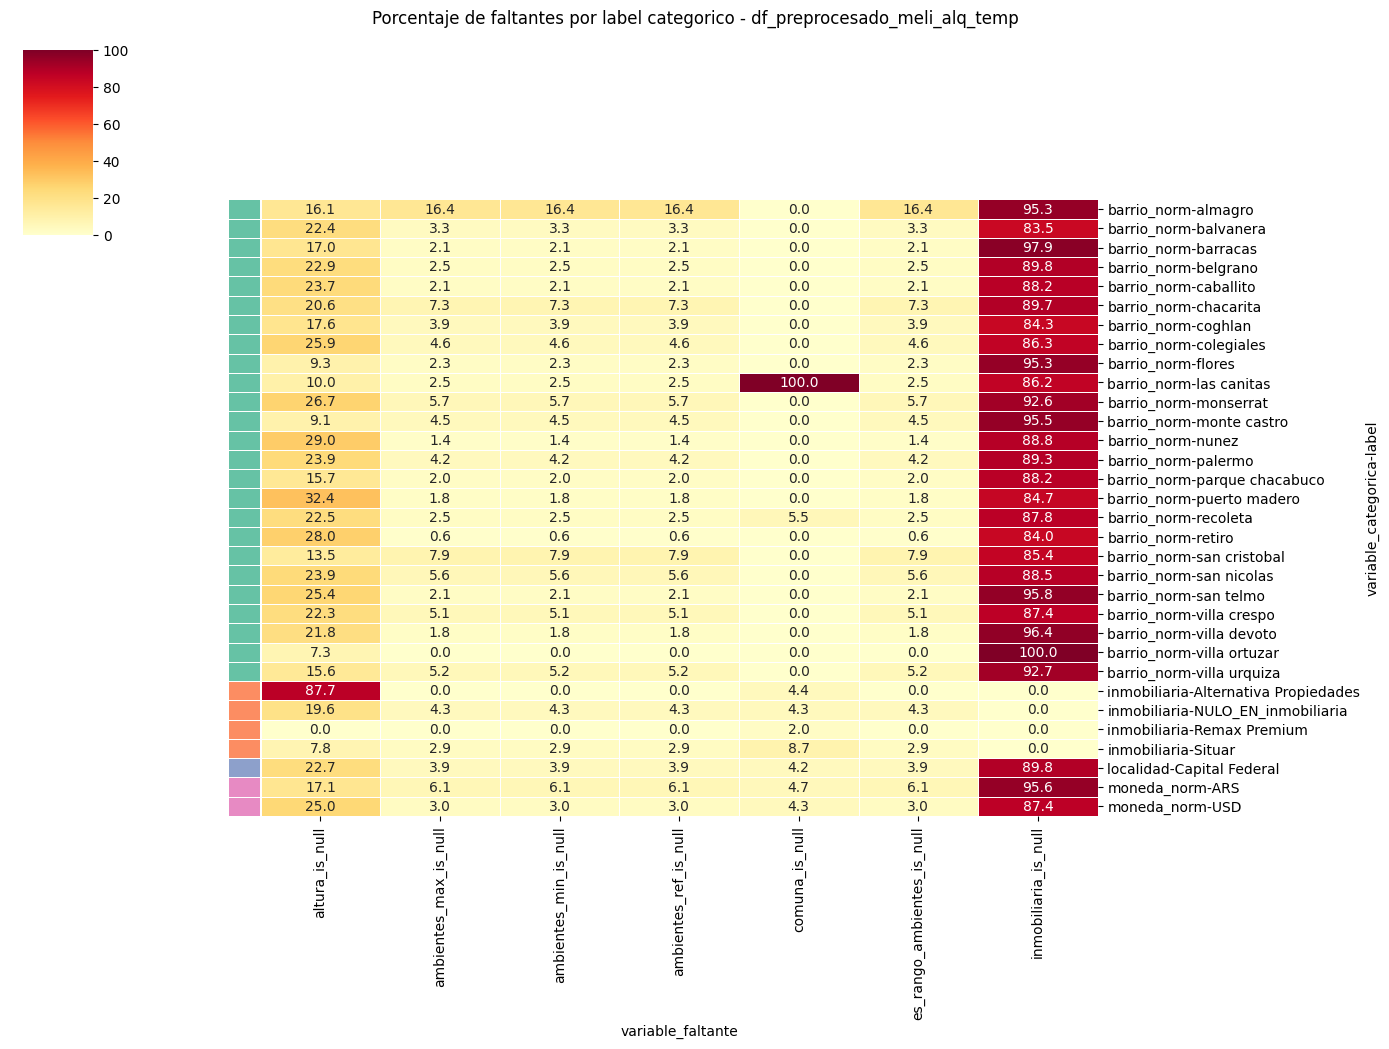


df_preprocesado_meli_vtas


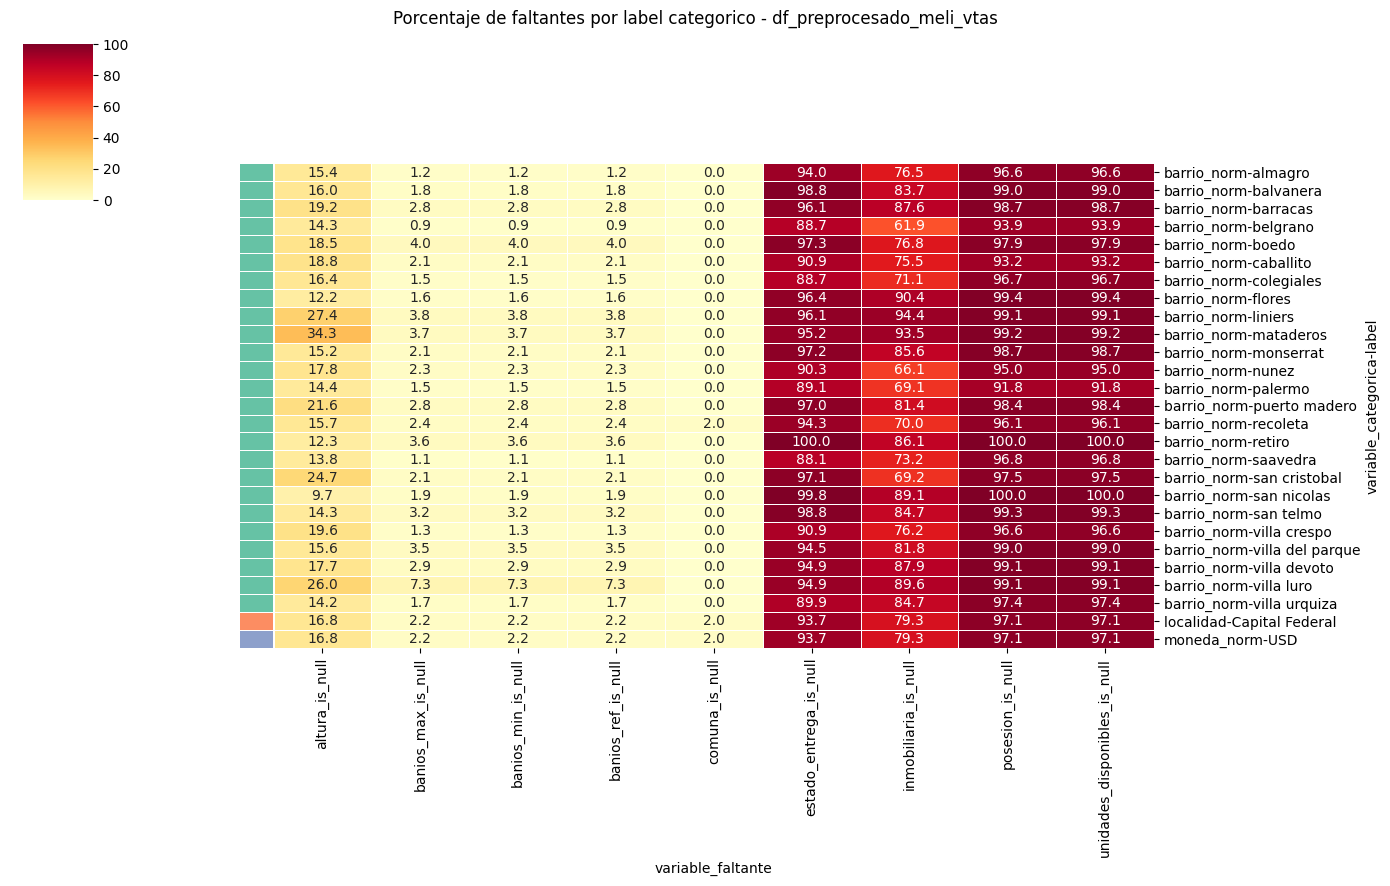


df_preprocesado_argenprop


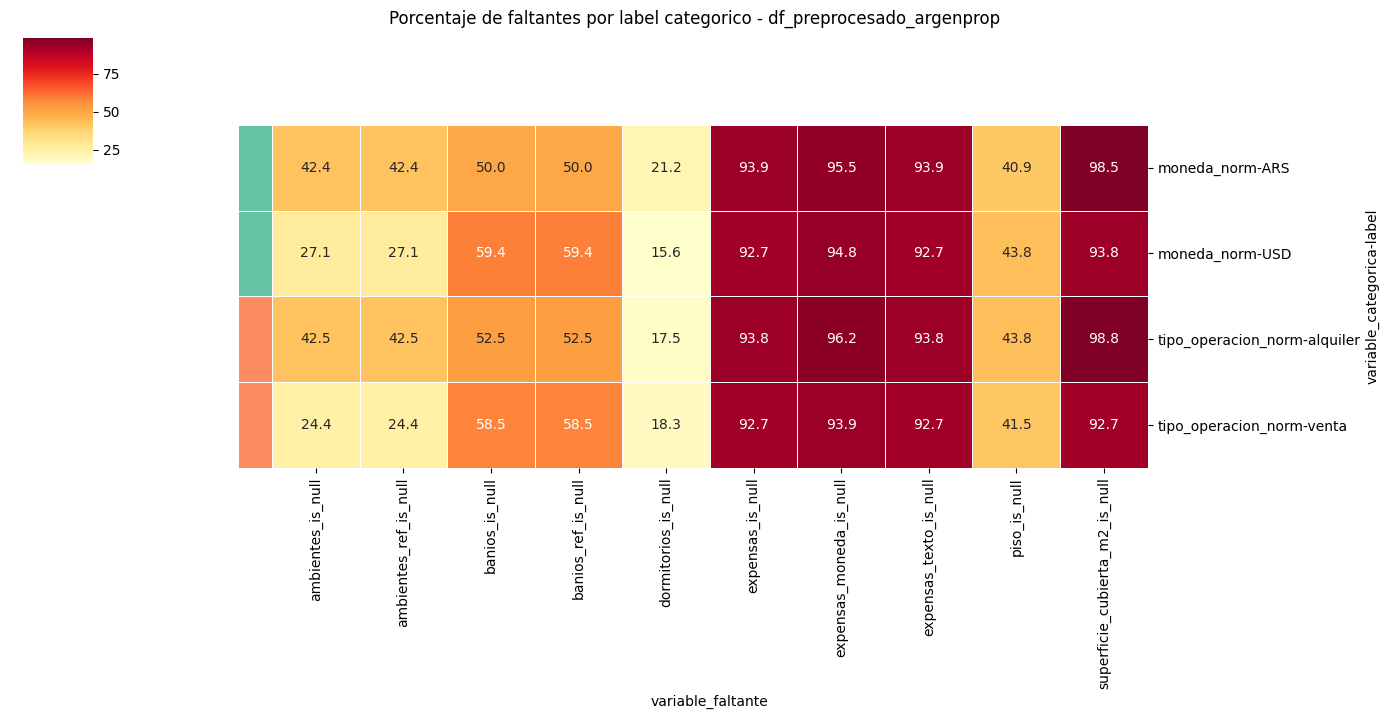


df_preprocesado_zonaprop


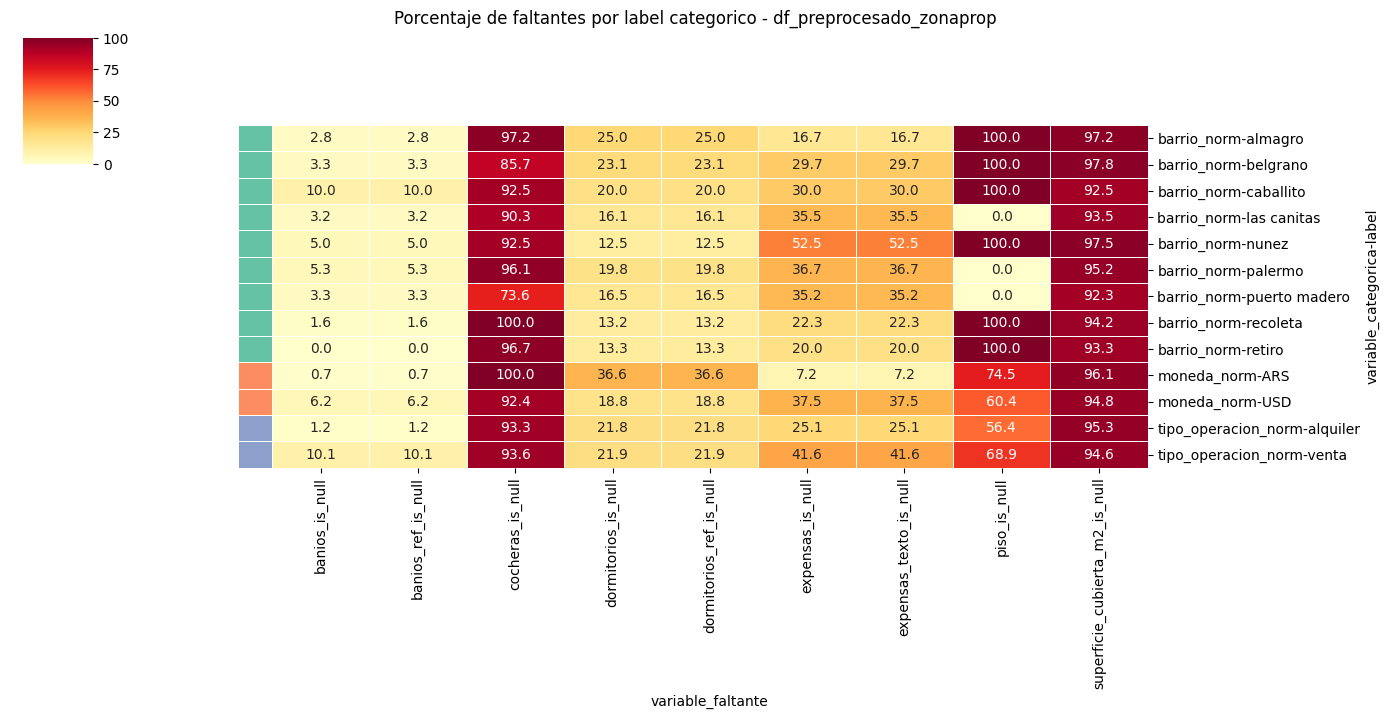


df_preprocesado_airbnb_temp


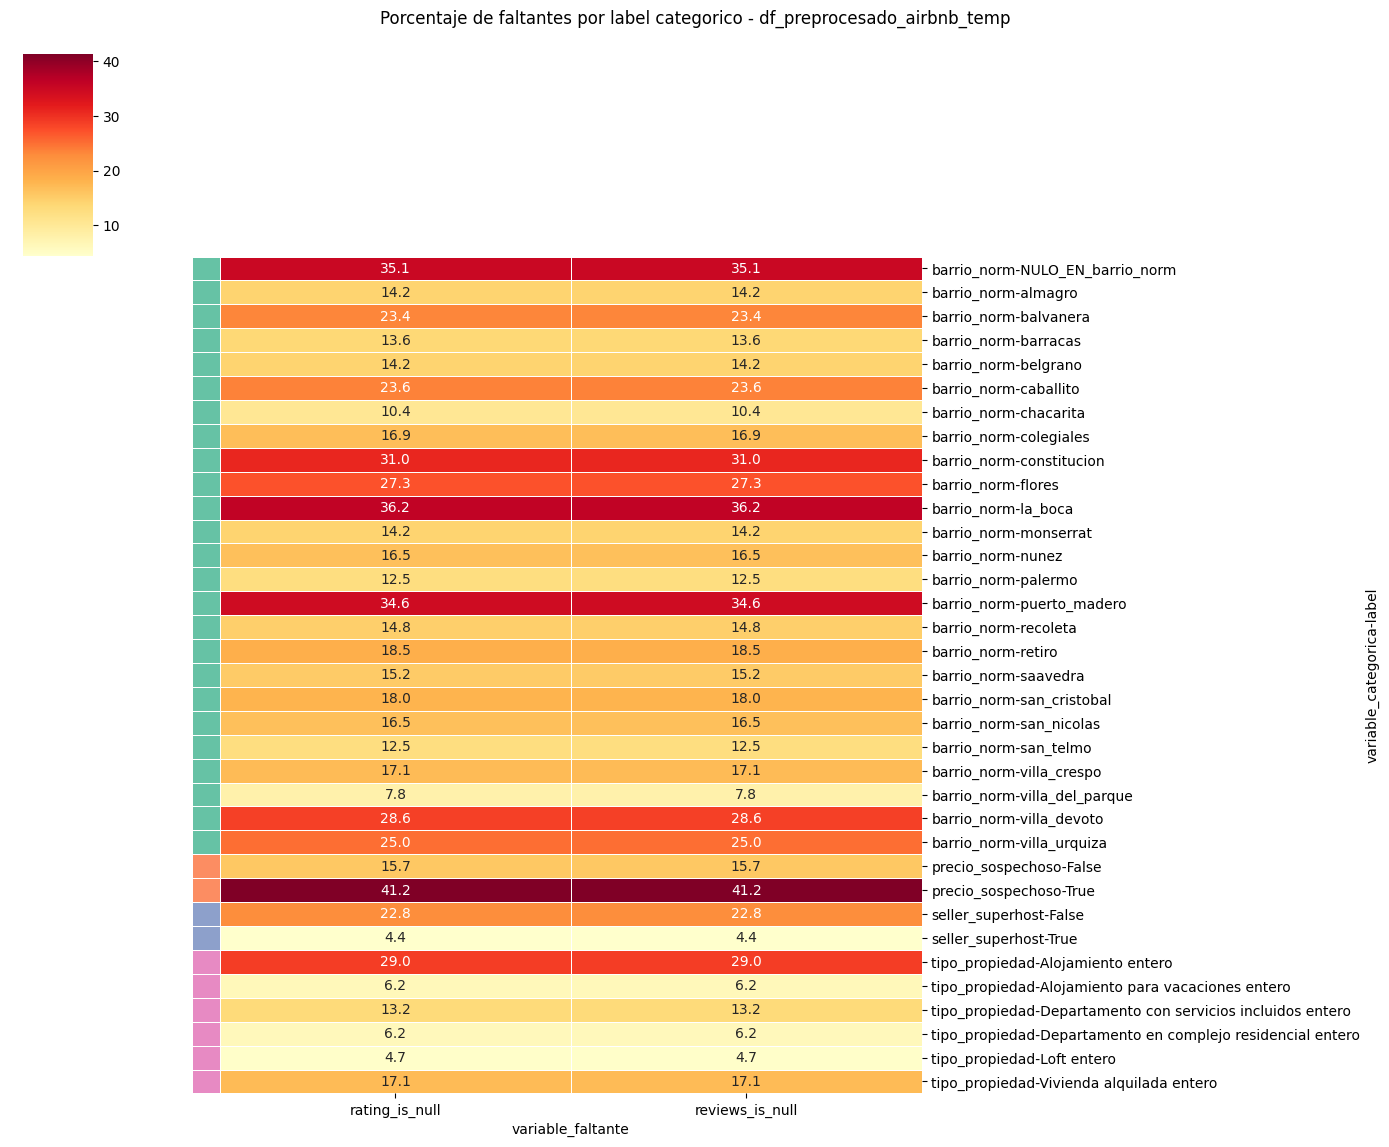

Reporte consolidado guardado: data\processed\reports\faltantes_por_label_categorico_todos_los_datasets.csv


In [7]:
resumenes_faltantes_por_label = []
for name, df in preprocesados_con_flags.items():
    print('\n' + '=' * 100)
    print(name)

    flags_diagnostico = seleccionar_flags_problematicos(df, min_pct=2, max_pct=98, top_n=10)
    cat_cols_diagnostico = seleccionar_categoricas_informativas(df, max_cols=6)

    if not flags_diagnostico:
        print('No hay flags de faltantes informativos para este dataset.')
        continue
    if not cat_cols_diagnostico:
        print('No hay variables categoricas informativas para este dataset.')
        continue

    df_faltantes_label_dataset = faltantes_por_labels_categoricos(df, cat_cols_diagnostico, flags_diagnostico, dataset_name=name, min_count=30, top_labels_por_col=25)
    if df_faltantes_label_dataset.empty:
        print('No hay combinaciones con volumen suficiente para graficar.')
        continue

    resumenes_faltantes_por_label.append(df_faltantes_label_dataset)
    df_faltantes_label_dataset.to_csv(REPORTS_DIR / f'faltantes_por_label_categorico_{name}.csv', index=False)
    graficar_faltantes_por_label(df_faltantes_label_dataset, dataset_name=name)

if resumenes_faltantes_por_label:
    df_faltantes_por_label_todos = pd.concat(resumenes_faltantes_por_label, ignore_index=True)
    df_faltantes_por_label_todos.to_csv(REPORTS_DIR / 'faltantes_por_label_categorico_todos_los_datasets.csv', index=False)
    print('Reporte consolidado guardado:', (REPORTS_DIR / 'faltantes_por_label_categorico_todos_los_datasets.csv').relative_to(REPO_ROOT))


# Conclusiones de faltantes por labels originales

Los faltantes se distribuyen de manera relativamente uniforme en varios barrios, pero aparecen excepciones útiles para decidir tratamiento. En particular, `Las Cañitas` muestra un faltante artificial de comuna por criterio de normalización geográfica. Además, Argenprop y Zonaprop todavía están combinados por fuente, por lo que la lectura por label se toma como diagnóstico inicial y no como cierre.

A partir de este punto se hacen ajustes controlados y luego se vuelven a mirar matrices/tablas:

1. Separar Argenprop y Zonaprop por tipo de operación.
2. Normalizar `Las Cañitas / las canitas` como Palermo y completar comuna 14.
3. Eliminar `localidad` cuando sea constante CABA, porque no aporta al análisis dentro del alcance del TP.
4. Conservar `moneda_norm`, aunque en algunos dataframes tenga una sola etiqueta, porque sigue siendo necesaria para comparar fuentes y operaciones.


In [8]:
# Guardado del diagnostico original con flags.
# Estos archivos conservan el estado previo a los ajustes decididos a partir de las matrices.
for name, df in preprocesados_con_flags.items():
    path = PROCESSED_DIR / f'{name}_con_flags_nulos_v1.csv'
    df.to_csv(path, index=False)
    print('Guardado diagnostico original:', path.relative_to(REPO_ROOT), df.shape)


Guardado diagnostico original: data\processed\df_preprocesado_meli_alq_con_flags_nulos_v1.csv (11479, 103)
Guardado diagnostico original: data\processed\df_preprocesado_meli_alq_temp_con_flags_nulos_v1.csv (6190, 104)
Guardado diagnostico original: data\processed\df_preprocesado_meli_vtas_con_flags_nulos_v1.csv (44013, 105)
Guardado diagnostico original: data\processed\df_preprocesado_argenprop_con_flags_nulos_v1.csv (162, 186)
Guardado diagnostico original: data\processed\df_preprocesado_zonaprop_con_flags_nulos_v1.csv (980, 189)
Guardado diagnostico original: data\processed\df_preprocesado_airbnb_temp_con_flags_nulos_v1.csv (9596, 90)


## Ajustes derivados del diagnóstico original

Estos ajustes no reemplazan el diagnóstico anterior: aparecen después porque son consecuencia de lo observado en matrices y tablas por label.

- `Las Cañitas / las canitas` se corrige puntualmente como `palermo` y se completa `comuna = 14`.
- `localidad` se elimina cuando es constante CABA, porque el alcance del TP ya está restringido a CABA.
- Argenprop y Zonaprop se separan en venta y alquiler para que los faltantes estructurales de cada operación no queden mezclados.


In [9]:
# Se parte de copias para conservar el diagnostico original sin pisarlo.
preprocesados_post_diagnostico = {name: df.copy() for name, df in preprocesados.items()}

# Correccion puntual detectada en el diagnostico anterior:
# Las Cañitas no es barrio oficial de CABA, sino subzona de Palermo.
for name, df in preprocesados_post_diagnostico.items():
    if {'barrio_norm', 'comuna'}.issubset(df.columns):
        mask_canitas = df['barrio_norm'].astype('string').str.lower().str.strip().isin(['las cañitas', 'las canitas'])
        df.loc[mask_canitas, 'barrio_norm'] = 'palermo'
        df.loc[mask_canitas, 'comuna'] = 14
        if mask_canitas.any():
            print(name, 'Las Cañitas normalizado como Palermo y comuna 14:', int(mask_canitas.sum()))

# Decision puntual de negocio: el TP analiza propiedades en CABA.
# Si localidad es constante CABA, se elimina porque no agrega segmentacion.
valores_caba = {'caba', 'capital federal', 'ciudad autonoma de buenos aires', 'ciudad autónoma de buenos aires'}
for name, df in list(preprocesados_post_diagnostico.items()):
    if 'localidad' in df.columns:
        localidades = set(df['localidad'].dropna().astype('string').str.lower().str.strip().unique())
        if len(localidades) <= 1 and localidades.issubset(valores_caba):
            preprocesados_post_diagnostico[name] = df.drop(columns=['localidad'])
            print(name, 'localidad eliminada por ser constante CABA')


def separar_por_operacion(nombre_base, df, mapeo_operaciones):
    resultado = {}
    categorias_presentes = set(df['tipo_operacion_norm'].dropna().unique())
    categorias_sin_mapear = categorias_presentes - set(mapeo_operaciones)
    if categorias_sin_mapear:
        print(f'AVISO [{nombre_base}]: categorias sin mapear, se excluyen: {categorias_sin_mapear}')
    for valor_operacion, sufijo in mapeo_operaciones.items():
        sub_df = df[df['tipo_operacion_norm'] == valor_operacion].copy()
        clave = f'{nombre_base}_{sufijo}'
        resultado[clave] = sub_df
        print(clave, sub_df.shape)
    return resultado

MAPEO_OPERACIONES_PORTALES = {'venta': 'vtas', 'alquiler': 'alq'}

preprocesados_post_ajustes = {
    name: df for name, df in preprocesados_post_diagnostico.items()
    if name not in {'df_preprocesado_argenprop', 'df_preprocesado_zonaprop'}
}
preprocesados_post_ajustes.update(separar_por_operacion('df_preprocesado_argenprop', preprocesados_post_diagnostico['df_preprocesado_argenprop'], MAPEO_OPERACIONES_PORTALES))
preprocesados_post_ajustes.update(separar_por_operacion('df_preprocesado_zonaprop', preprocesados_post_diagnostico['df_preprocesado_zonaprop'], MAPEO_OPERACIONES_PORTALES))

preprocesados_post_ajustes_con_flags = {}
for name, df in preprocesados_post_ajustes.items():
    preprocesados_post_ajustes_con_flags[name] = add_null_flags(df)
    globals()[f'{name}_post_ajustes'] = preprocesados_post_ajustes_con_flags[name]

print('\nDatasets generados post-ajustes:')
for name, df in preprocesados_post_ajustes_con_flags.items():
    print(name, df.shape)


df_preprocesado_meli_alq Las Cañitas normalizado como Palermo y comuna 14: 42
df_preprocesado_meli_alq_temp Las Cañitas normalizado como Palermo y comuna 14: 80
df_preprocesado_meli_vtas Las Cañitas normalizado como Palermo y comuna 14: 139
df_preprocesado_meli_alq localidad eliminada por ser constante CABA
df_preprocesado_argenprop localidad eliminada por ser constante CABA
df_preprocesado_zonaprop localidad eliminada por ser constante CABA
df_preprocesado_airbnb_temp localidad eliminada por ser constante CABA
df_preprocesado_argenprop_vtas (82, 106)
df_preprocesado_argenprop_alq (80, 106)
df_preprocesado_zonaprop_vtas (485, 106)
df_preprocesado_zonaprop_alq (495, 106)

Datasets generados post-ajustes:
df_preprocesado_meli_alq (11479, 102)
df_preprocesado_meli_alq_temp (6190, 104)
df_preprocesado_meli_vtas (44013, 105)
df_preprocesado_airbnb_temp (9596, 89)
df_preprocesado_argenprop_vtas (82, 183)
df_preprocesado_argenprop_alq (80, 184)
df_preprocesado_zonaprop_vtas (485, 187)
df_prep

# Tratamientos

En esta sección se empiezan a aplicar decisiones sobre los nulos detectados. El flujo es simple:

1. Primero se eliminan columnas estructurales: `localidad` cuando es constante CABA y columnas con 100% de nulos.
2. Después de separar Argenprop y Zonaprop por operación, se revisan las columnas con muchos nulos.
3. Para esas columnas dudosas solo hay tres decisiones posibles:
   - borrarla si no aporta información usable;
   - mantenerla si tiene muchos nulos en un dataframe pero aparece con datos en otros;
   - marcarla como susceptible de reconstrucción si puede recuperarse desde texto, atributos u otras columnas.

No se imputan columnas completas sin evidencia. Si una columna no entra en ninguno de esos casos, se elimina.


### Eliminación de columnas estructurales

Estas decisiones se aplican sobre los dataframes **post-separación**, es decir, después de dividir Argenprop y Zonaprop en venta y alquiler. Así evitamos tomar decisiones mezclando operaciones con estructuras distintas.

| Caso | Decisión | Motivo |
|---|---|---|
| `localidad` constante CABA | Eliminar | El alcance del TP ya está restringido a CABA; no aporta segmentación. |
| Columna con 100% de nulos en un dataframe | Eliminar | No tiene datos observados en esa fuente. |
| Columna con muchos nulos pero presente con datos en otros dataframes | Mantener por ahora | Puede servir para comparar fuentes o quedar disponible cuando el dato existe. |
| Columna con muchos nulos pero recuperable desde texto, atributos u otra columna | Mantener para reconstrucción | Antes de eliminarla conviene intentar recuperarla. |
| Columna con muchos nulos, sin datos en otros dataframes y sin reconstrucción clara | Eliminar | No aporta información usable para esta etapa. |


In [10]:
# Eliminacion de localidad constante y columnas 100% nulas, ya con Argenprop/Zonaprop separados.

DATASETS_POST_AJUSTES_A_COMPARAR = [
    'df_preprocesado_argenprop_vtas',
    'df_preprocesado_argenprop_alq',
    'df_preprocesado_zonaprop_vtas',
    'df_preprocesado_zonaprop_alq',
]

COLUMNAS_A_DROPPEAR_POR_DATASET = {}

valores_caba = {'caba', 'capital federal', 'ciudad autonoma de buenos aires', 'ciudad autónoma de buenos aires'}

for name, df in preprocesados_post_ajustes.items():
    columnas_a_droppear = []

    if 'localidad' in df.columns:
        localidades = set(df['localidad'].dropna().astype('string').str.lower().str.strip().unique())
        if len(localidades) <= 1 and localidades.issubset(valores_caba):
            columnas_a_droppear.append('localidad')

    columnas_100_nulas = [
        col for col in df.columns
        if df[col].isna().mean() == 1
    ]
    columnas_a_droppear.extend(columnas_100_nulas)

    columnas_a_droppear = sorted(set(columnas_a_droppear))
    COLUMNAS_A_DROPPEAR_POR_DATASET[name] = columnas_a_droppear

    print('\n' + '=' * 100)
    print(name)
    print('Columnas 100% nulas:', columnas_100_nulas if columnas_100_nulas else 'ninguna')
    print('Columnas a droppear ahora:', columnas_a_droppear if columnas_a_droppear else 'ninguna')

APLICAR_DROP_COLUMNAS_ESTRUCTURALES = True

if APLICAR_DROP_COLUMNAS_ESTRUCTURALES:
    preprocesados_post_ajustes = {
        name: df.drop(columns=COLUMNAS_A_DROPPEAR_POR_DATASET.get(name, []), errors='ignore')
        for name, df in preprocesados_post_ajustes.items()
    }
    print('\nDrop de columnas estructurales aplicado sobre datasets post-separacion.')
else:
    print('\nNo se aplico el drop. Revisar COLUMNAS_A_DROPPEAR_POR_DATASET antes de ejecutar.')

# Se regeneran flags despues del drop para que las siguientes tablas y guardados usen el estado actualizado.
preprocesados_post_ajustes_con_flags = {}
for name, df in preprocesados_post_ajustes.items():
    preprocesados_post_ajustes_con_flags[name] = add_null_flags(df)
    globals()[f'{name}_post_ajustes'] = preprocesados_post_ajustes_con_flags[name]

preprocesados_post_ajustes_para_comparar = {
    name: preprocesados_post_ajustes_con_flags[name]
    for name in DATASETS_POST_AJUSTES_A_COMPARAR
    if name in preprocesados_post_ajustes_con_flags
}



df_preprocesado_meli_alq
Columnas 100% nulas: ['posesion', 'unidades_disponibles', 'parse_warnings']
Columnas a droppear ahora: ['parse_warnings', 'posesion', 'unidades_disponibles']

df_preprocesado_meli_alq_temp
Columnas 100% nulas: ['parse_warnings']
Columnas a droppear ahora: ['parse_warnings']

df_preprocesado_meli_vtas
Columnas 100% nulas: ['parse_warnings']
Columnas a droppear ahora: ['parse_warnings']

df_preprocesado_airbnb_temp
Columnas 100% nulas: ['superficie_ref_m2', 'precio_m2_ref']
Columnas a droppear ahora: ['precio_m2_ref', 'superficie_ref_m2']

df_preprocesado_argenprop_vtas
Columnas 100% nulas: ['descripcion', 'estado_publicacion', 'fecha_publicacion', 'inmobiliaria', 'seller_id', 'unidad', 'barrio', 'partido', 'provincia', 'pais', 'codigo_postal', 'latitud', 'longitud', 'toilettes', 'superficie_descubierta_m2', 'superficie_semicubierta_m2', 'superficie_terreno_m2', 'frente_m', 'fondo_m', 'antiguedad_anios', 'estado_inmueble', 'disposicion', 'orientacion', 'luminosi

### Revisión de columnas con muchos nulos

Después de eliminar las columnas 100% vacías, revisamos las columnas con muchos nulos. El umbral se usa como alerta, no como regla automática de borrado.

Para cada columna se decide una de estas opciones:

| Decisión | Cuándo aplica |
|---|---|
| `borrar` | Tiene muchos nulos, no aparece con datos en otros dataframes y no hay forma clara de reconstruirla. |
| `mantener_por_otros_dfs` | Tiene muchos nulos en este dataframe, pero aparece con datos en otros dataframes. |
| `reconstruir` | Puede recuperarse desde texto, atributos, URL u otra columna. |

Las columnas candidatas se revisan sobre `preprocesados_post_ajustes`, es decir, con Argenprop y Zonaprop ya separados por operación.


In [11]:
UMBRAL_NULOS_ALTO = 0.80

COLUMNAS_SUSCEPTIBLES_RECONSTRUCCION = {
    'expensas',
    'expensas_texto',
    'cocheras',
    'dormitorios_ref',
    'dormitorios_min',
    'dormitorios_max',
    'ambientes_ref',
    'banios_ref',
    'superficie_ref_m2',
    'precio_m2_ref',
    'estado_entrega',
    'posesion',
    'inmobiliaria',
}

registros_revision_nulos_altos = []

for name, df in preprocesados_post_ajustes.items():
    otros_dfs = {
        other_name: other_df
        for other_name, other_df in preprocesados_post_ajustes.items()
        if other_name != name
    }

    for col in df.columns:
        pct_nulos = df[col].isna().mean()
        if pct_nulos < UMBRAL_NULOS_ALTO:
            continue

        aparece_con_datos_en_otros = any(
            col in other_df.columns and other_df[col].notna().any()
            for other_df in otros_dfs.values()
        )
        es_reconstruible = col in COLUMNAS_SUSCEPTIBLES_RECONSTRUCCION

        if es_reconstruible:
            decision_sugerida = 'reconstruir'
        elif aparece_con_datos_en_otros:
            decision_sugerida = 'mantener_por_otros_dfs'
        else:
            decision_sugerida = 'borrar'

        registros_revision_nulos_altos.append({
            'dataset': name,
            'columna': col,
            'pct_nulos': round(pct_nulos * 100, 2),
            'n_no_nulos': int(df[col].notna().sum()),
            'aparece_con_datos_en_otros_dfs': aparece_con_datos_en_otros,
            'susceptible_reconstruccion': es_reconstruible,
            'decision_sugerida': decision_sugerida,
        })

df_revision_nulos_altos = (
    pd.DataFrame(registros_revision_nulos_altos)
    .sort_values(['dataset', 'decision_sugerida', 'pct_nulos', 'columna'], ascending=[True, True, False, True])
)

display(df_revision_nulos_altos)


,dataset,columna,pct_nulos,n_no_nulos,aparece_con_datos_en_otros_dfs,susceptible_reconstruccion,decision_sugerida
32,df_preprocesado_argenprop_alq,superficie_cubierta_m2,98.75,1,True,False,mantener_por_otros_dfs
29,df_preprocesado_argenprop_alq,expensas_moneda,96.25,3,True,False,mantener_por_otros_dfs
30,df_preprocesado_argenprop_alq,expensas,93.75,5,True,True,reconstruir
31,df_preprocesado_argenprop_alq,expensas_texto,93.75,5,True,True,reconstruir
24,df_preprocesado_argenprop_vtas,expensas_moneda,93.90,5,True,False,mantener_por_otros_dfs
28,df_preprocesado_argenprop_vtas,superficie_cubierta_m2,92.68,6,True,False,mantener_por_otros_dfs
27,df_preprocesado_argenprop_vtas,cocheras,96.34,3,True,True,reconstruir
25,df_preprocesado_argenprop_vtas,expensas,92.68,6,True,True,reconstruir
26,df_preprocesado_argenprop_vtas,expensas_texto,92.68,6,True,True,reconstruir
4,df_preprocesado_meli_alq,descuento_pct,99.82,21,True,False,mantener_por_otros_dfs


Las columnas con muchos nulos no se tratan todas igual. Si aparecen con datos en otros dataframes, se mantienen para no perder compatibilidad entre fuentes. Si pueden reconstruirse, se reservan para una regla posterior. Si no cumplen ninguna de esas condiciones, se eliminan.


In [12]:
# Aplicacion de decisiones sobre columnas con muchos nulos.
# Se borran solo las marcadas como borrar en la tabla anterior.

COLUMNAS_NULOS_ALTOS_A_DROPPEAR = {}

if not df_revision_nulos_altos.empty:
    df_a_borrar = df_revision_nulos_altos[df_revision_nulos_altos['decision_sugerida'] == 'borrar']
    COLUMNAS_NULOS_ALTOS_A_DROPPEAR = (
        df_a_borrar
        .groupby('dataset')['columna']
        .apply(list)
        .to_dict()
    )

print('Columnas con nulos altos a droppear:')
for name, cols in COLUMNAS_NULOS_ALTOS_A_DROPPEAR.items():
    print(name, cols)

APLICAR_DROP_NULOS_ALTOS = True

if APLICAR_DROP_NULOS_ALTOS:
    for name, cols in COLUMNAS_NULOS_ALTOS_A_DROPPEAR.items():
        if name not in preprocesados_post_ajustes:
            continue
        cols_existentes = [col for col in cols if col in preprocesados_post_ajustes[name].columns]
        preprocesados_post_ajustes[name] = preprocesados_post_ajustes[name].drop(columns=cols_existentes)
        print(name, 'columnas eliminadas por nulos altos:', cols_existentes)

    preprocesados_post_ajustes_con_flags = {}
    for name, df in preprocesados_post_ajustes.items():
        preprocesados_post_ajustes_con_flags[name] = add_null_flags(df)
        globals()[f'{name}_post_ajustes'] = preprocesados_post_ajustes_con_flags[name]

    preprocesados_post_ajustes_para_comparar = {
        name: preprocesados_post_ajustes_con_flags[name]
        for name in DATASETS_POST_AJUSTES_A_COMPARAR
        if name in preprocesados_post_ajustes_con_flags
    }
else:
    print('No se eliminan columnas con nulos altos automaticamente.')


Columnas con nulos altos a droppear:


### Resultado del bloque de eliminación

A partir de este punto, los dataframes de trabajo son los contenidos en `preprocesados_post_ajustes` y `preprocesados_post_ajustes_con_flags`. Argenprop y Zonaprop ya están separados por operación, y las columnas eliminadas corresponden a:

- columnas con 100% de nulos;
- `localidad` cuando no aporta variabilidad;
- columnas con muchos nulos que no aparecen con datos en otros dataframes y no fueron marcadas como reconstruibles.


### Datasets post-ajustes que se vuelven a comparar

Para no repetir información, la segunda lectura muestra solo los cuatro dataframes nuevos separados por operación. MeLi y Airbnb ya fueron revisados en la lectura original; acá el objetivo es verificar qué cambia al dividir Argenprop y Zonaprop en venta/alquiler.


In [13]:
DATASETS_POST_AJUSTES_A_COMPARAR = [
    'df_preprocesado_argenprop_vtas',
    'df_preprocesado_argenprop_alq',
    'df_preprocesado_zonaprop_vtas',
    'df_preprocesado_zonaprop_alq',
]

preprocesados_post_ajustes_para_comparar = {
    name: preprocesados_post_ajustes_con_flags[name]
    for name in DATASETS_POST_AJUSTES_A_COMPARAR
    if name in preprocesados_post_ajustes_con_flags
}

print('Datasets post-ajustes incluidos en la comparacion:')
for name, df in preprocesados_post_ajustes_para_comparar.items():
    print(name, df.shape)


Datasets post-ajustes incluidos en la comparacion:
df_preprocesado_argenprop_vtas (82, 61)
df_preprocesado_argenprop_alq (80, 60)
df_preprocesado_zonaprop_vtas (485, 63)
df_preprocesado_zonaprop_alq (495, 58)


## Matrices post-ajustes para comparar

Estas matrices son una segunda lectura. No eliminan las matrices originales: sirven para verificar si las decisiones tomadas reducen faltantes artificiales o separan patrones que estaban mezclados.



df_preprocesado_argenprop_vtas


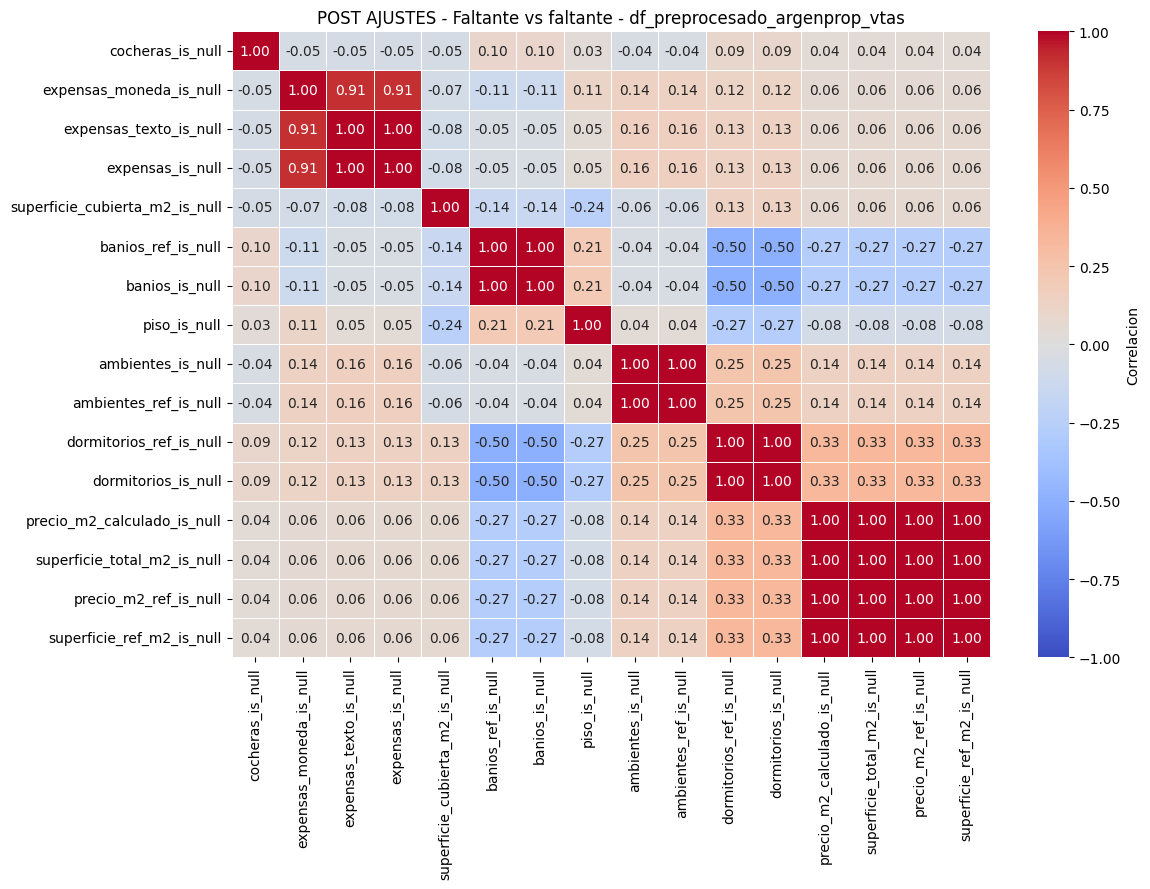

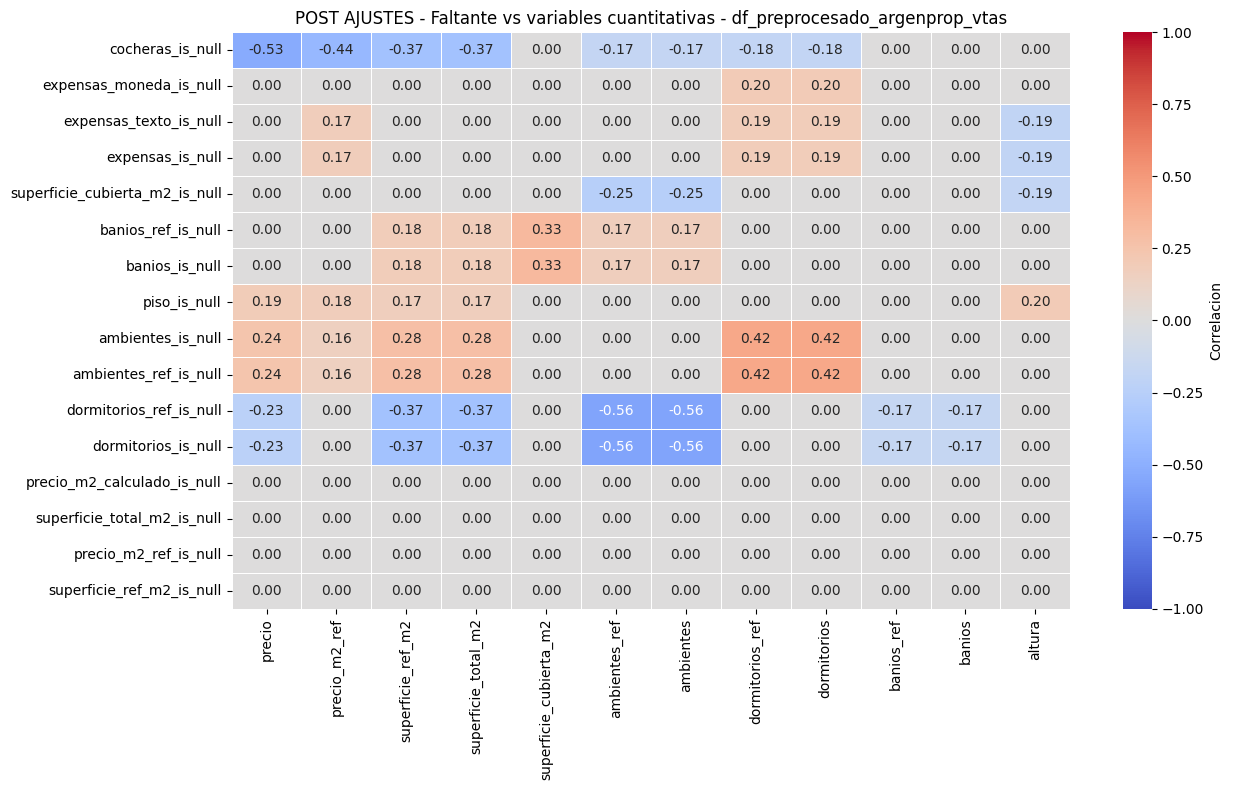


df_preprocesado_argenprop_alq


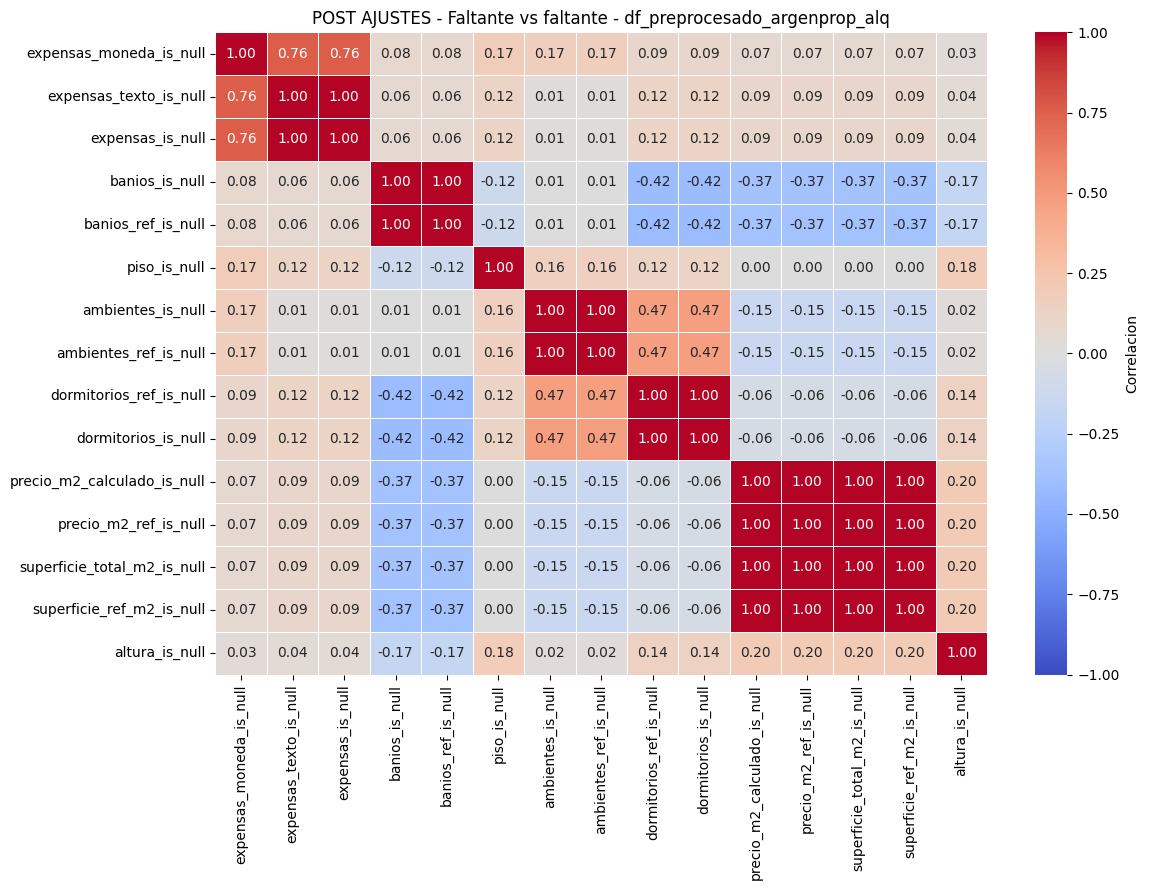

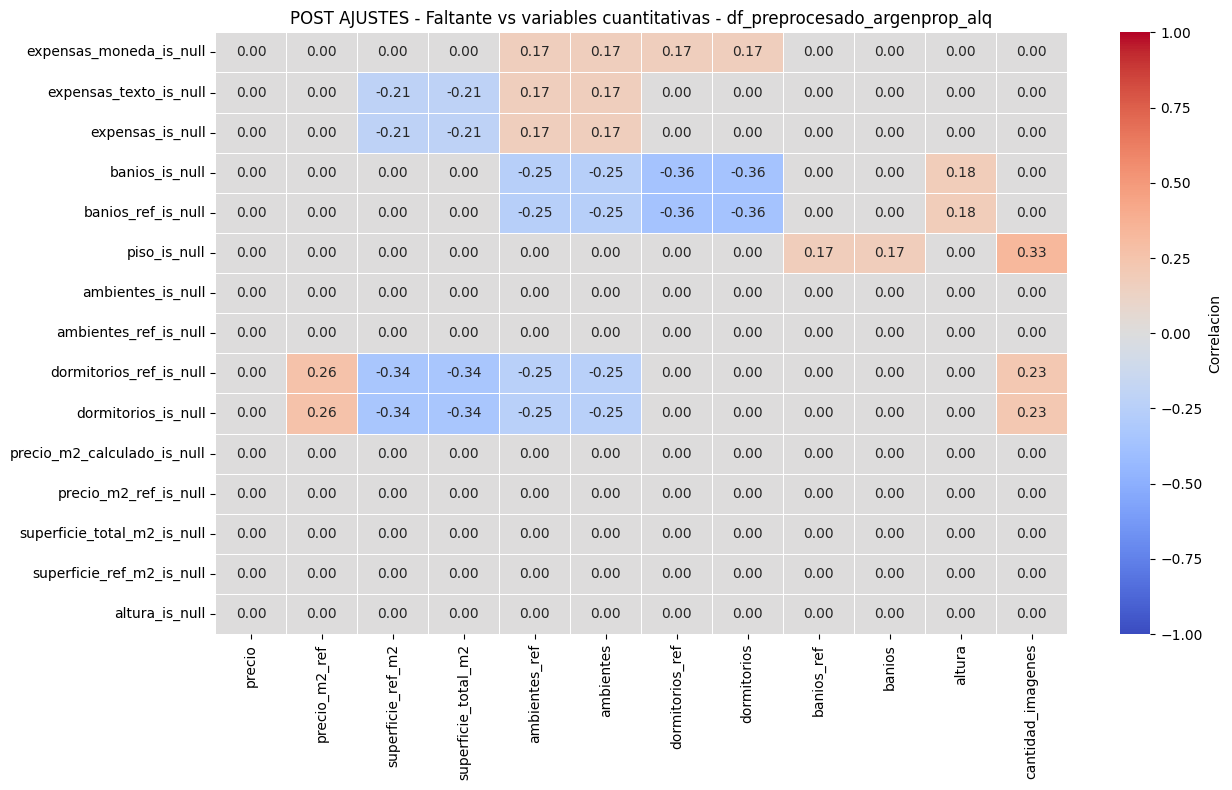


df_preprocesado_zonaprop_vtas


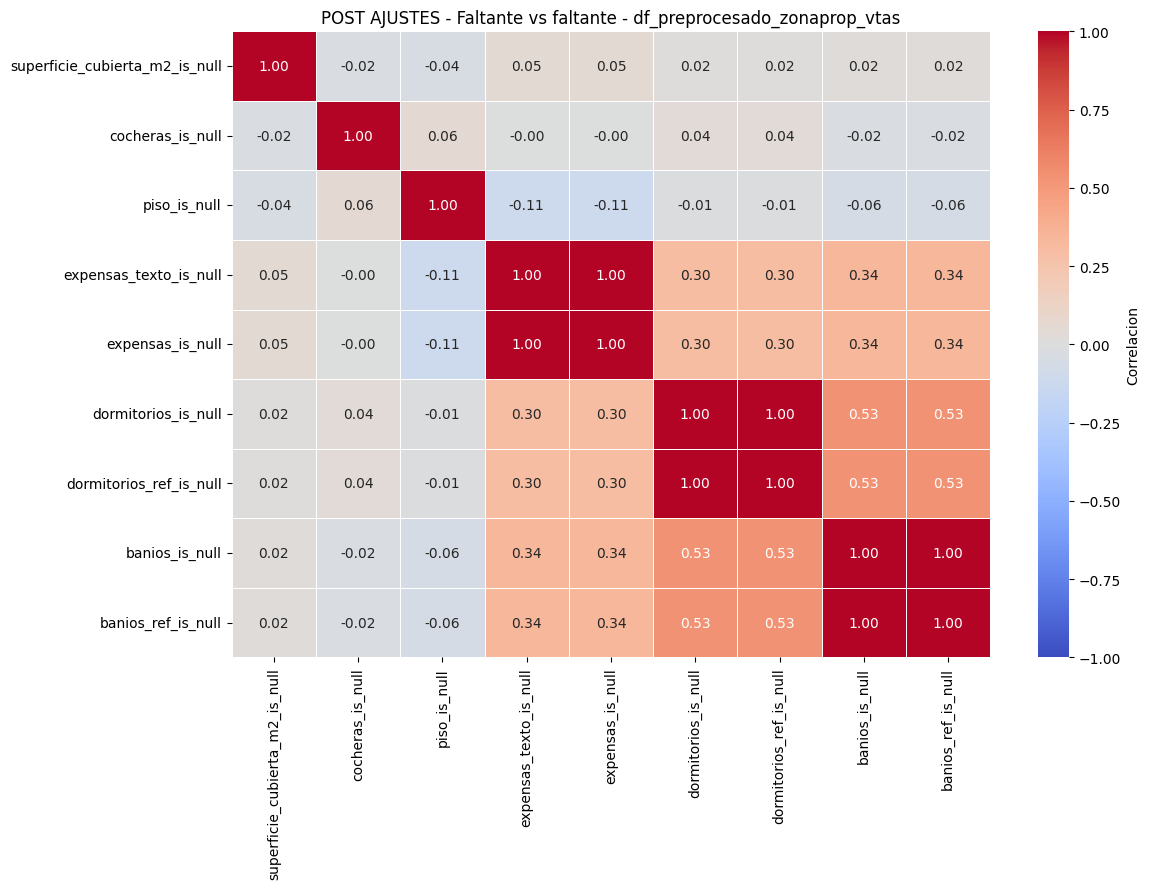

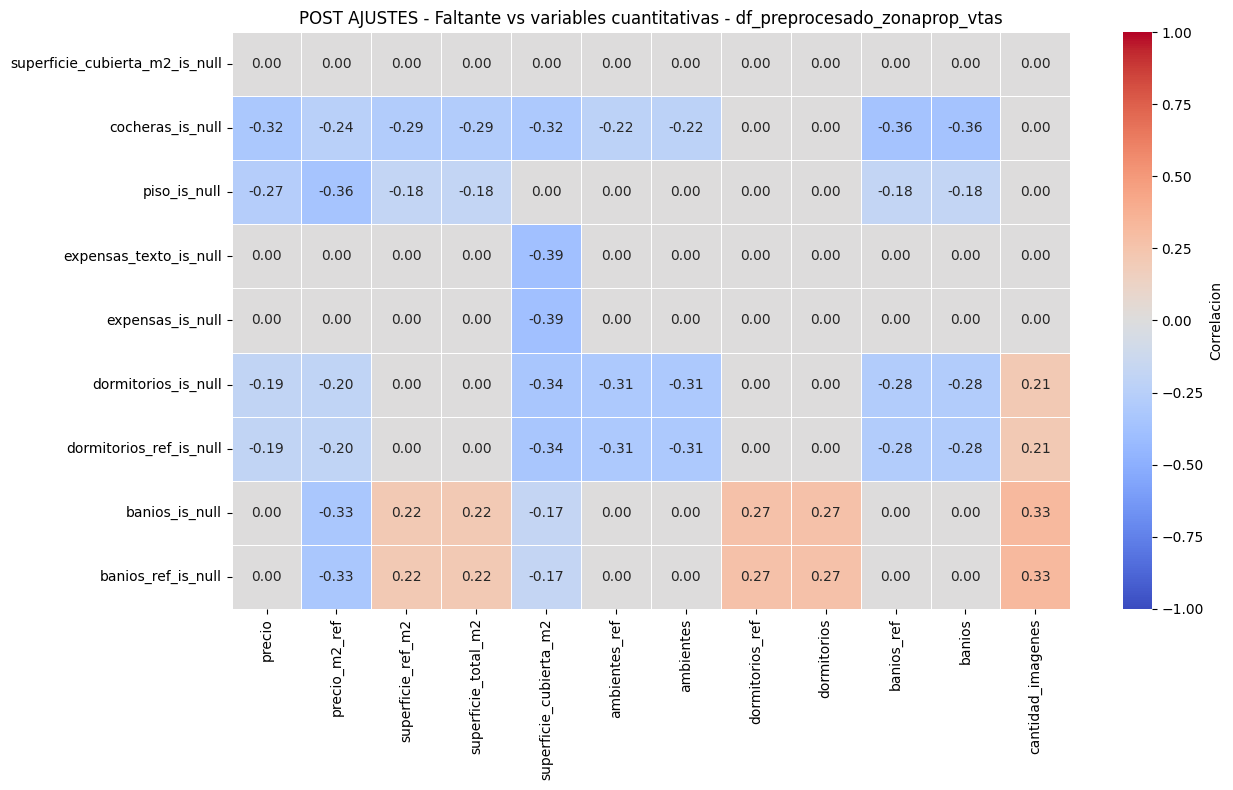


df_preprocesado_zonaprop_alq


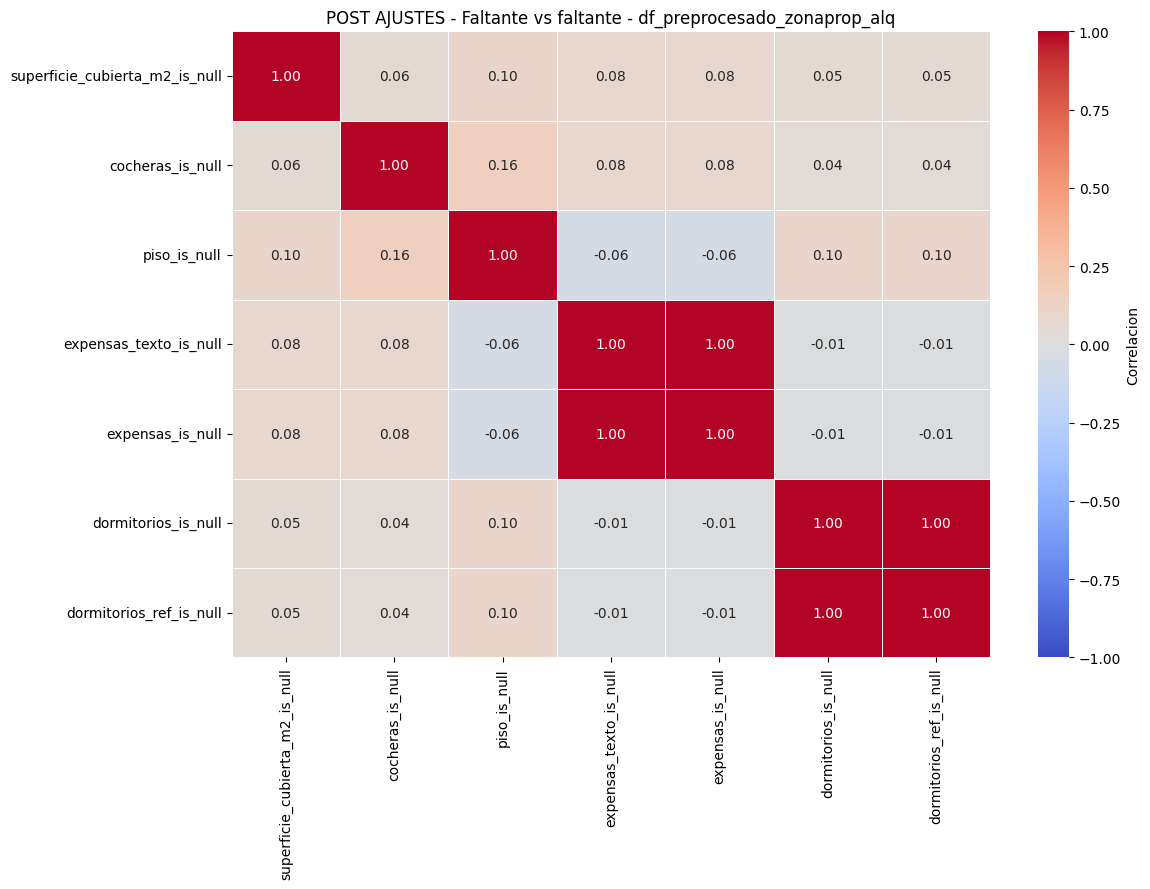

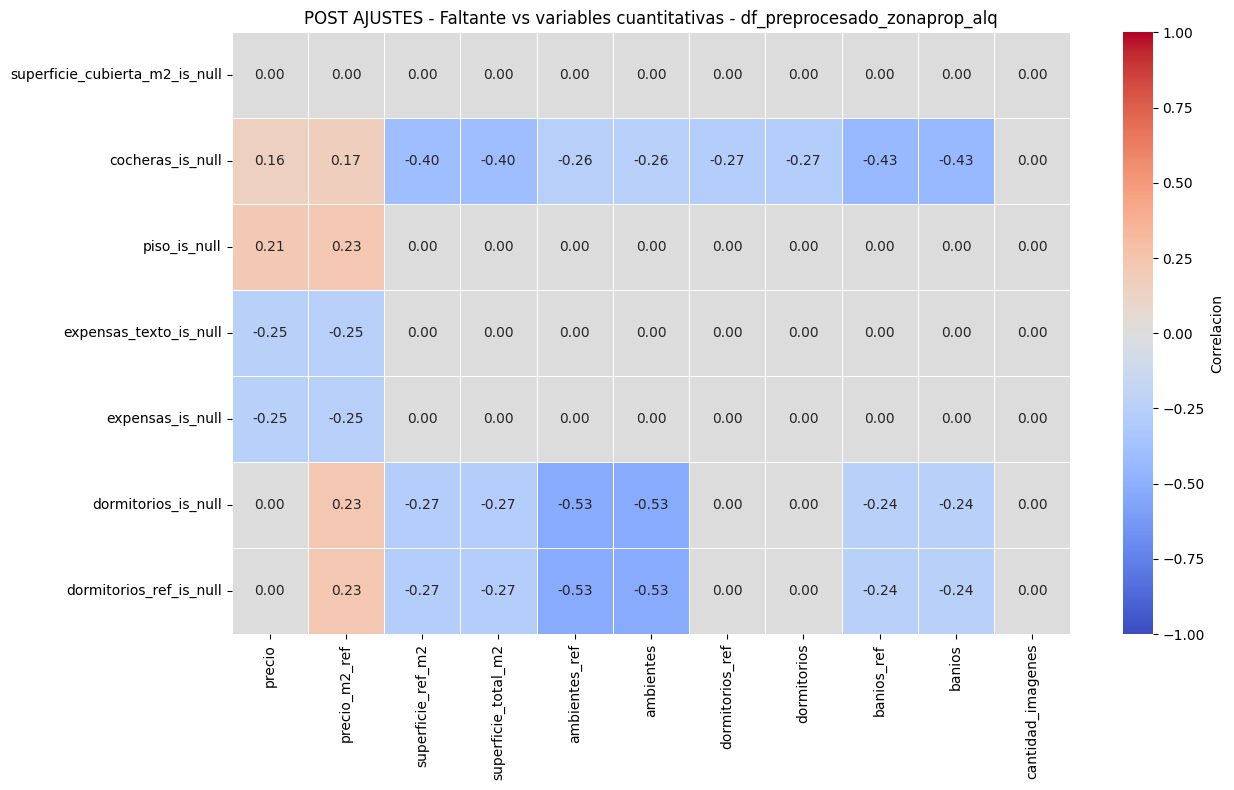

In [14]:
for name, df in preprocesados_post_ajustes_para_comparar.items():
    print('\n' + '=' * 100)
    print(name)

    flags = seleccionar_flags_informativos(df, min_pct=2, max_pct=98, max_flags=16)
    cuantitativas = seleccionar_cuantitativas_informativas(df, max_vars=12)

    if len(flags) < 2:
        print('No hay suficientes flags informativos de faltantes para este dataset.')
        continue

    matriz_faltante_faltante = df[flags].corr()
    matriz_faltante_faltante.to_csv(REPORTS_DIR / f'matriz_faltante_vs_faltante_post_ajustes_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_faltante, title=f'POST AJUSTES - Faltante vs faltante - {name}', figsize=(12, 9), annot=True, mostrar_nan_como_cero=True)

    if len(cuantitativas) == 0:
        print('No hay variables cuantitativas informativas para cruzar contra faltantes.')
        continue

    matriz_faltante_cuantitativa = df[flags + cuantitativas].corr(numeric_only=True).loc[flags, cuantitativas]
    umbral_corr_cuantitativas = 0.15
    matriz_faltante_cuantitativa_filtrada = matriz_faltante_cuantitativa.where(matriz_faltante_cuantitativa.abs() >= umbral_corr_cuantitativas, other=0)
    matriz_faltante_cuantitativa.to_csv(REPORTS_DIR / f'matriz_faltante_vs_cuantitativas_post_ajustes_{name}.csv')
    plot_heatmap_matriz(matriz_faltante_cuantitativa_filtrada, title=f'POST AJUSTES - Faltante vs variables cuantitativas - {name}', figsize=(13, 8), annot=True, mostrar_nan_como_cero=True)


## Faltantes por label post-ajustes

Se repite el cruce contra variables categóricas para verificar si los labels problemáticos siguen mostrando faltantes concentrados después de separar operaciones y corregir el caso geográfico detectado.



df_preprocesado_argenprop_vtas
No hay combinaciones con volumen suficiente para graficar.

df_preprocesado_argenprop_alq


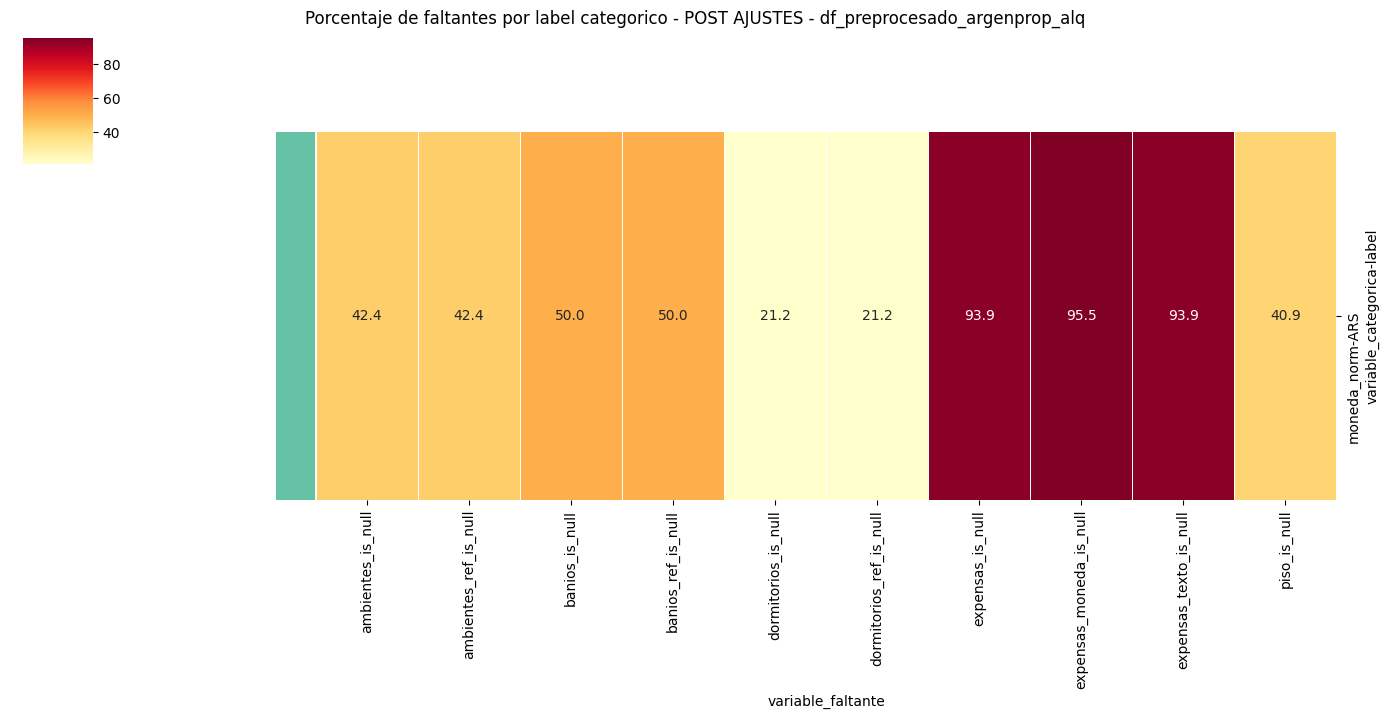


df_preprocesado_zonaprop_vtas


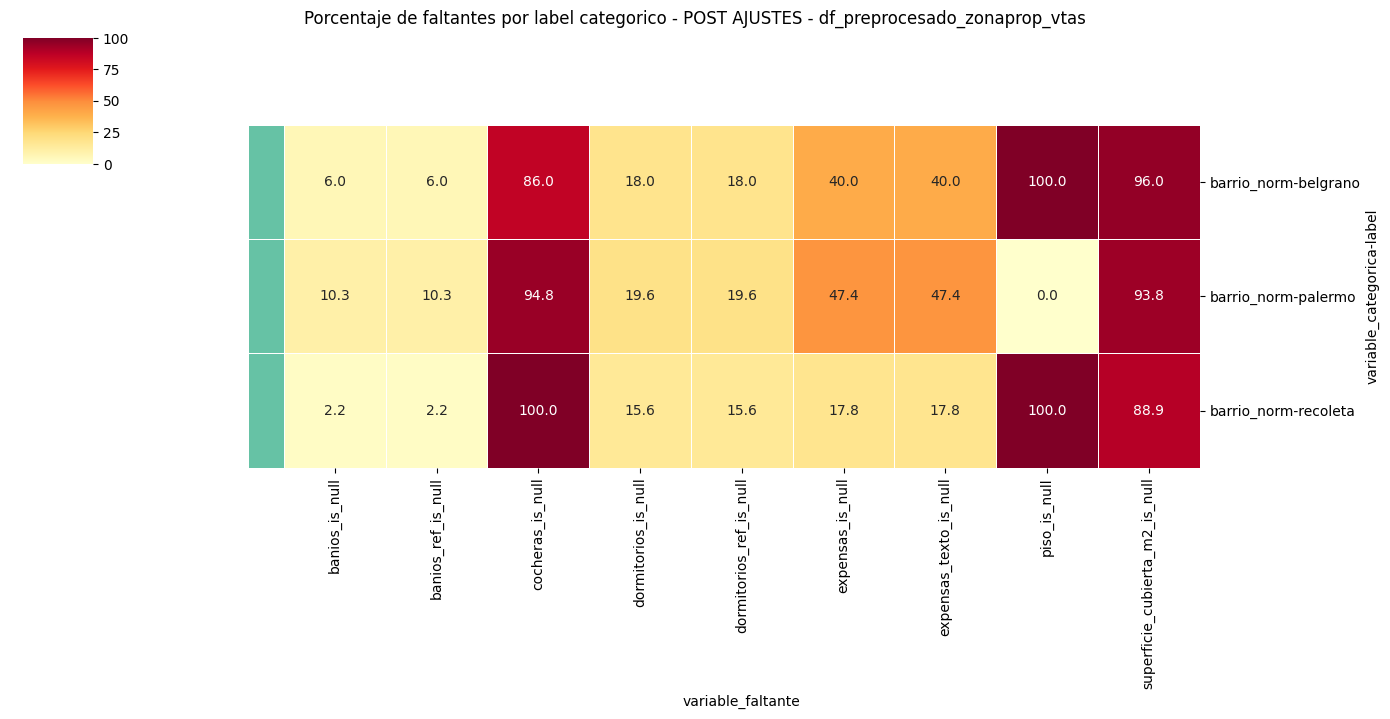


df_preprocesado_zonaprop_alq


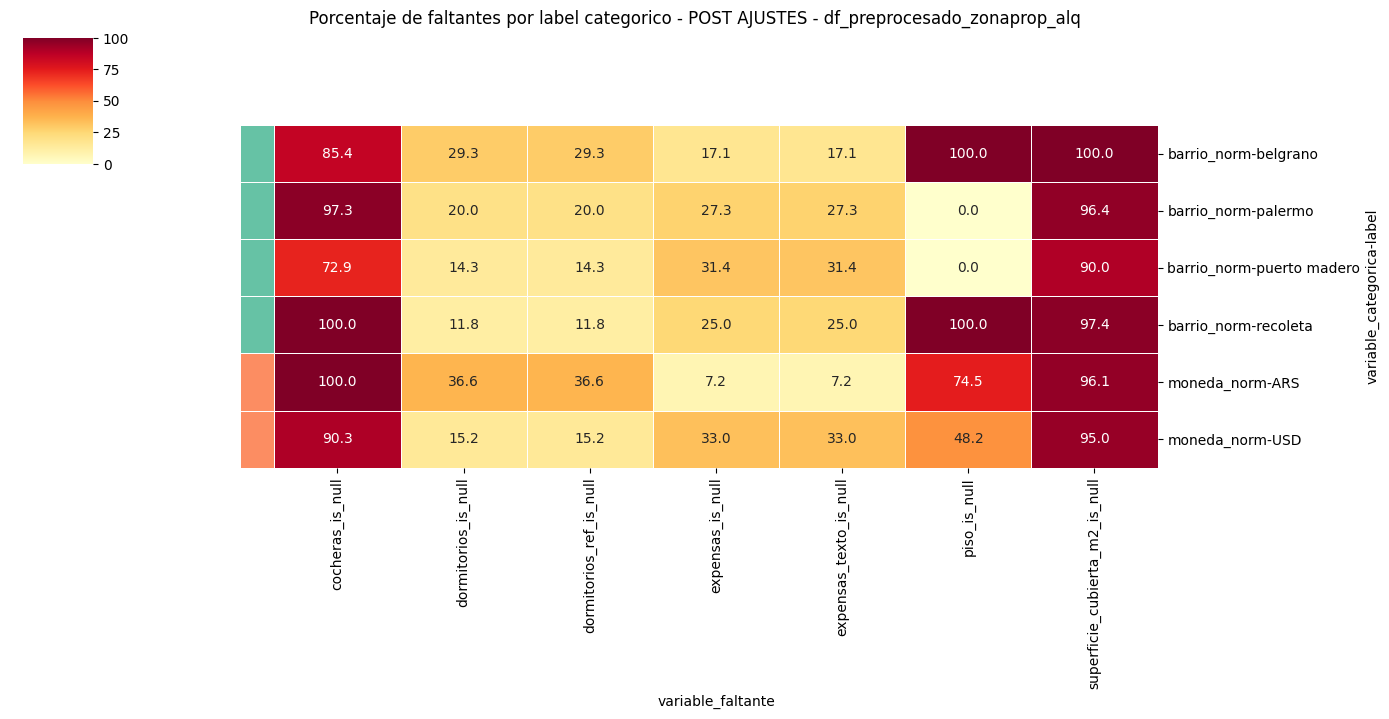

Reporte post-ajustes guardado: data\processed\reports\faltantes_por_label_categorico_post_ajustes_todos_los_datasets.csv


In [15]:
resumenes_faltantes_por_label_post = []
for name, df in preprocesados_post_ajustes_para_comparar.items():
    print('\n' + '=' * 100)
    print(name)

    flags_diagnostico = seleccionar_flags_problematicos(df, min_pct=2, max_pct=98, top_n=10)
    cat_cols_diagnostico = seleccionar_categoricas_informativas(df, max_cols=6)

    if not flags_diagnostico:
        print('No hay flags de faltantes informativos para este dataset.')
        continue
    if not cat_cols_diagnostico:
        print('No hay variables categoricas informativas para este dataset.')
        continue

    df_faltantes_label_dataset = faltantes_por_labels_categoricos(df, cat_cols_diagnostico, flags_diagnostico, dataset_name=name, min_count=30, top_labels_por_col=25)
    if df_faltantes_label_dataset.empty:
        print('No hay combinaciones con volumen suficiente para graficar.')
        continue

    resumenes_faltantes_por_label_post.append(df_faltantes_label_dataset)
    df_faltantes_label_dataset.to_csv(REPORTS_DIR / f'faltantes_por_label_categorico_post_ajustes_{name}.csv', index=False)
    graficar_faltantes_por_label(df_faltantes_label_dataset, dataset_name=f'POST AJUSTES - {name}')

if resumenes_faltantes_por_label_post:
    df_faltantes_por_label_post_todos = pd.concat(resumenes_faltantes_por_label_post, ignore_index=True)
    df_faltantes_por_label_post_todos.to_csv(REPORTS_DIR / 'faltantes_por_label_categorico_post_ajustes_todos_los_datasets.csv', index=False)
    print('Reporte post-ajustes guardado:', (REPORTS_DIR / 'faltantes_por_label_categorico_post_ajustes_todos_los_datasets.csv').relative_to(REPO_ROOT))


## Guardado de versiones post-ajustes


In [16]:
# Guardado post-ajustes. Se usa otro sufijo para no pisar el diagnostico original.
for name, df in preprocesados_post_ajustes_para_comparar.items():
    path = PROCESSED_DIR / f'{name}_post_ajustes_con_flags_nulos_v1.csv'
    df.to_csv(path, index=False)
    print('Guardado post-ajustes:', path.relative_to(REPO_ROOT), df.shape)


Guardado post-ajustes: data\processed\df_preprocesado_argenprop_vtas_post_ajustes_con_flags_nulos_v1.csv (82, 61)
Guardado post-ajustes: data\processed\df_preprocesado_argenprop_alq_post_ajustes_con_flags_nulos_v1.csv (80, 60)
Guardado post-ajustes: data\processed\df_preprocesado_zonaprop_vtas_post_ajustes_con_flags_nulos_v1.csv (485, 63)
Guardado post-ajustes: data\processed\df_preprocesado_zonaprop_alq_post_ajustes_con_flags_nulos_v1.csv (495, 58)


## Cierre del análisis de nulos

El notebook conserva dos momentos:

1. **Diagnóstico original:** matrices y tablas sobre los datasets tal como llegan desde la normalización inicial.
2. **Post-ajustes:** matrices y tablas después de decisiones tomadas a partir del diagnóstico: separación de Argenprop/Zonaprop por operación, corrección de Las Cañitas como Palermo y eliminación de `localidad` cuando es constante CABA.

Esta estructura muestra el recorrido del análisis: primero se observa el problema, después se toma una decisión y finalmente se vuelve a comparar el resultado.


### Imputaciones o reconstrucciones

| DataFrame(s) | Columna / familia | Hacer | Motivo | Estado |
|---|---|---|---|---|
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq`, `df_preprocesado_airbnb_temp` | `precio` | No imputar; excluir solo de KPIs de precio cuando falte. | Es variable objetivo/central; inventarla distorsiona cualquier indicador monetario. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `moneda_norm` | No imputar; reconstruir solo si `precio_texto` trae símbolo claro. | Sin moneda no se puede comparar precio ni convertir ARS/USD. Se conserva aunque en algunos datasets tenga una sola etiqueta. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq`, `df_preprocesado_airbnb_temp` | `barrio_norm` | Reconstruir desde barrio, dirección o coordenadas; si no hay evidencia, excluir de análisis geográfico. | Es clave para hipótesis territoriales y cruces con fuentes externas. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `comuna` | Recalcular desde `barrio_norm` cuando exista mapeo oficial. | Es derivable; evita faltantes artificiales como `Las Cañitas`. | Parcialmente aplicado para Las Cañitas |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `superficie_ref_m2` | Reconstruir desde superficies equivalentes o texto explícito; no imputar media/mediana. | Define precio/m² y tipología; una imputación promedio altera el inmueble. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `precio_m2_ref` | Recalcular cuando existan `precio` y `superficie_ref_m2` válidos. | Es una variable derivada, no observada; debe seguir la calidad de sus componentes. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq`, `df_preprocesado_airbnb_temp` | `ambientes_ref` | Reconstruir desde mínimos/máximos o texto explícito. | La cantidad de ambientes define comparabilidad; no conviene inferir sin evidencia. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq`, `df_preprocesado_airbnb_temp` | `dormitorios_ref` | Mantener nulo salvo mención explícita; evaluar regla especial para monoambientes. | Muchos portales publican ambientes y no dormitorios; no son equivalentes directos. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq`, `df_preprocesado_airbnb_temp` | `banios_ref` | Reconstruir desde mínimos/máximos, atributos o texto explícito. | Es una variable estructural relevante; no imputar moda. | Propuesto |
| `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `expensas` | Parsear desde texto si aparece; no reemplazar por 0. | No informado no significa sin expensas. | Propuesto |


In [17]:
COLUMNAS_A_IMPUTAR_O_RECONSTRUIR = {
    # Se completa al cerrar reglas definitivas.
    # Ejemplo: 'comuna': 'recalcular_desde_barrio_norm'
}

APLICAR_IMPUTACIONES = False

if APLICAR_IMPUTACIONES:
    raise NotImplementedError('Completar reglas aprobadas antes de activar imputaciones/reconstrucciones.')
else:
    print('No se aplican imputaciones automaticas. Se conserva el criterio conservador con flags.')


No se aplican imputaciones automaticas. Se conserva el criterio conservador con flags.


### Otros tratamientos

| DataFrame(s) | Columna / familia | Hacer | Motivo | Estado |
|---|---|---|---|---|
| `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `latitud` / `longitud` | No imputar coordenada real; si se usan centroides, crear columnas `*_aprox`. | Mezclar coordenadas reales y aproximadas rompe la interpretabilidad espacial. | Propuesto |
| `df_preprocesado_meli_alq`, `df_preprocesado_meli_alq_temp`, `df_preprocesado_meli_vtas`, `df_preprocesado_argenprop_vtas`, `df_preprocesado_argenprop_alq`, `df_preprocesado_zonaprop_vtas`, `df_preprocesado_zonaprop_alq` | `inmobiliaria` | Usar `no_informado` solo para gráficos; mantener flag para análisis. | El faltante puede ser informativo del portal o tipo de publicación. | Propuesto |
| `df_preprocesado_airbnb_temp` | `seller_superhost`, `review_scores_rating`, `number_of_reviews` | Mantener nulos y flags; no imputar promedio. | En Airbnb puede indicar ausencia de reseñas o de perfil completo, no calidad media. | Propuesto |
| `df_preprocesado_meli_vtas`, `df_preprocesado_meli_alq_temp` | `estado_entrega` / `posesion` | Usar como variable secundaria; reconstruir desde texto si aparece. | Es muy incompleta, pero relevante en ventas, emprendimientos y disponibilidad temporal. | Propuesto |


In [18]:
OTROS_TRATAMIENTOS = {
    # Ejemplos futuros:
    # 'texto_analisis': 'titulo + descripcion + texto_tarjeta',
    # 'latitud_aprox_longitud_aprox': 'centroide_barrio_o_comuna'
}

APLICAR_OTROS_TRATAMIENTOS = False

if APLICAR_OTROS_TRATAMIENTOS:
    raise NotImplementedError('Completar reglas aprobadas antes de activar otros tratamientos.')
else:
    print('No se aplican otros tratamientos automaticos. Quedan documentados para la etapa final.')


No se aplican otros tratamientos automaticos. Quedan documentados para la etapa final.
